In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statsmodels.tsa.seasonal import STL

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Donnees_ hydro_Togo/"
DATE_FORMAT = None
DATE_COL = "Date"

Mounted at /content/drive


In [3]:
Ttou = path+"Qj_Tetetou.csv"
Dtkp = path+"Qj_Dotaicope.csv"
Klkp = path+"Qj_kolokope.csv"

Ttou_df = pd.read_csv(Ttou, sep=';', skiprows=[0])
Dtkp_df = pd.read_csv(Dtkp, sep=';', skiprows=[0])
Klkp_df = pd.read_csv(Klkp, sep=';', skiprows=[0])

stations = ["Tetetou", "Dotaicope", "Kolokope"]

In [4]:
# @title Traitement des VM (N/A)
for stat in stations:
  if stat == "Tetetou":
    if DATE_FORMAT:
        Ttou_df[DATE_COL] = pd.to_datetime(Ttou_df[DATE_COL], format=DATE_FORMAT)
        Ttou_df = Ttou_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Ttou_df = Ttou_df[Ttou_df['Qj(m3/s)'] >= 0]
        Ttou_df['Qj'] = np.where(Ttou_df['Qj'] < 0, np.nan, Ttou_df['Qj'])
        Ttou_df = Ttou_df.drop(columns=['Unnamed: 2'])
        Ttou_df = Ttou_df.set_index('Date').sort_index()
        # Ttou_df = Ttou_df.to_frame(name='Qj')
    else:
        Ttou_df[DATE_COL] = pd.to_datetime(Ttou_df[DATE_COL], dayfirst=True, errors='coerce')
        Ttou_df = Ttou_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Ttou_df = Ttou_df[Ttou_df['Qj(m3/s)'] >= 0]
        Ttou_df['Qj'] = np.where(Ttou_df['Qj'] < 0, np.nan, Ttou_df['Qj'])
        Ttou_df = Ttou_df.drop(columns=['Unnamed: 2'])
        Ttou_df = Ttou_df.set_index('Date').sort_index()
        # Ttou_df = Ttou_df.to_frame(name='Qj')
  elif stat == "Dotaicope":
    if DATE_FORMAT:
        Dtkp_df[DATE_COL] = pd.to_datetime(Dtkp_df[DATE_COL], format=DATE_FORMAT)
        df = df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Dtkp_df = Dtkp_df[df['Qj(m3/s)'] >= 0]
        Dtkp_df['Qj'] = np.where(Dtkp_df['Qj'] < 0, np.nan, Dtkp_df['Qj'])
        Dtkp_df = Dtkp_df.drop(columns=['Unnamed: 2'])
        Dtkp_df = Dtkp_df.set_index('Date').sort_index()
        # Dtkp_df = Dtkp_df.to_frame(name='Qj')
    else:
        Dtkp_df[DATE_COL] = pd.to_datetime(Dtkp_df[DATE_COL], dayfirst=True, errors='coerce')
        Dtkp_df = Dtkp_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Dtkp_df = Dtkp_df[Dtkp_df['Qj(m3/s)'] >= 0]
        Dtkp_df['Qj'] = np.where(Dtkp_df['Qj'] < 0, np.nan, Dtkp_df['Qj'])
        Dtkp_df = Dtkp_df.drop(columns=['Unnamed: 2'])
        Dtkp_df = Dtkp_df.set_index('Date').sort_index()
        # Dtkp_df = Dtkp_df.to_frame(name='Qj')
  elif stat == "Kolokope":
      if DATE_FORMAT:
        Klkp_df[DATE_COL] = pd.to_datetime(Klkp_df[DATE_COL], format=DATE_FORMAT)
        Klkp_df = Klkp_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # df = Klkp_df[Klkp_df['Qj(m3/s)'] >= 0]
        Klkp_df['Qj'] = np.where(Klkp_df['Qj'] < 0, np.nan, Klkp_df['Qj'])
        df = Klkp_df.drop(columns=['Unnamed: 2'])
        df = Klkp_df.set_index('Date').sort_index()
        # Klkp_df = Klkp_df.to_frame(name='Qj')
      else:
        Klkp_df[DATE_COL] = pd.to_datetime(Klkp_df[DATE_COL], dayfirst=True, errors='coerce')
        Klkp_df = Klkp_df.rename(columns={'Qj(m3/s)': 'Qj'})
        # Klkp_df = Klkp_df[Klkp_df['Qj(m3/s)'] >= 0]
        Klkp_df['Qj'] = np.where(Klkp_df['Qj'] < 0, np.nan, Klkp_df['Qj'])
        Klkp_df = Klkp_df.drop(columns=['Unnamed: 2'])
        Klkp_df = Klkp_df.set_index('Date').sort_index()
        # Klkp_df = Klkp_df.to_frame(name='Qj')

In [5]:
for stat in stations:
  if stat == "Tetetou":
    Ttou_month_max = Ttou_df[['Qj']].dropna()
    Ttou_month_max = Ttou_month_max[['Qj']].resample('ME').max()
    Ttou_month_max = Ttou_month_max.dropna()
    t_month_date_series = Ttou_month_max.index
  elif stat == "Dotaicope":
    Dtkp_month_max = Dtkp_df[['Qj']].dropna()
    Dtkp_month_max = Dtkp_month_max[['Qj']].resample('ME').max()
    Dtkp_month_max = Dtkp_month_max.dropna()
    d_month_date_series = Dtkp_month_max.index
  elif stat == "Kolokope":
    Klkp_month_max = Klkp_df[['Qj']].dropna()
    Klkp_month_max = Klkp_month_max[['Qj']].resample('ME').max()
    Klkp_month_max = Klkp_month_max.dropna()
    k_month_date_series = Klkp_month_max.index

In [6]:
# @title Importation et fusion des données meteo de la nasa avec les débits journaliers

meteo_path = "/content/drive/MyDrive/Donnees_ hydro_Togo/Donnees_meteo_nasa/"

met_tetetou = pd.read_csv(meteo_path+"tetetou_meteo_data.csv")
met_dotaicope = pd.read_csv(meteo_path+"Dotaikope_meteo_data.csv")
met_kolokope = pd.read_csv(meteo_path+"Correkope_meteo_data.csv")

met_df = met_tetetou.iloc[:-4]
med_df = met_dotaicope.iloc[:-4]
mec_df = met_kolokope.iloc[:-4]

met_df = met_df.copy()
med_df = med_df.copy()
mec_df = mec_df.copy()

met_df['Date'] = pd.to_datetime(met_df[['YEAR', 'MO', 'DY']].rename(columns={
    'YEAR': 'year',
    'MO': 'month',
    'DY': 'day'
}))

med_df['Date'] = pd.to_datetime(med_df[['YEAR', 'MO', 'DY']].rename(columns={
    'YEAR': 'year',
    'MO': 'month',
    'DY': 'day'
}))

mec_df['Date'] = pd.to_datetime(mec_df[['YEAR', 'MO', 'DY']].rename(columns={
    'YEAR': 'year',
    'MO': 'month',
    'DY': 'day'
}))

met_df = met_df.drop(columns=['YEAR', 'MO', 'DY'])
med_df = med_df.drop(columns=['YEAR', 'MO', 'DY'])
mec_df = mec_df.drop(columns=['YEAR', 'MO', 'DY'])

Ttou_df = Ttou_df.reset_index()
Dtkp_df = Dtkp_df.reset_index()
Klkp_df = Klkp_df.reset_index()

NMTdf_final = pd.merge(Ttou_df, met_df, on='Date', how='inner')
NMTdf_final = NMTdf_final.set_index('Date')

NMDdf_final = pd.merge(Dtkp_df, met_df, on='Date', how='inner')
NMDdf_final = NMDdf_final.set_index('Date')

NMCdf_final = pd.merge(Klkp_df, met_df, on='Date', how='inner')
NMCdf_final = NMCdf_final.set_index('Date')

In [7]:
# @title Maximum debit && meteo mensuel
Ttou_df.index = pd.to_datetime(Ttou_df.index)
Dtkp_df.index = pd.to_datetime(Dtkp_df.index)
Klkp_df.index = pd.to_datetime(Klkp_df.index)

Ttou_df = Ttou_df.set_index('Date')
Dtkp_df = Dtkp_df.set_index('Date')
Klkp_df = Klkp_df.set_index('Date')

met_df = met_df.set_index('Date')
med_df = med_df.set_index('Date')
mec_df = mec_df.set_index('Date')

t_idx_max = Ttou_df['Qj'].resample('ME').apply(lambda x: x.idxmax() if not x.dropna().empty else None)
d_idx_max = Dtkp_df['Qj'].resample('ME').apply(lambda x: x.idxmax() if not x.dropna().empty else None)
c_idx_max = Klkp_df['Qj'].resample('ME').apply(lambda x: x.idxmax() if not x.dropna().empty else None)

# 3. On nettoie les valeurs None (mois sans données)
t_idx_max = t_idx_max.dropna()
d_idx_max = d_idx_max.dropna()
c_idx_max = c_idx_max.dropna()

# 4. On récupère les lignes correspondantes
Ttou_exact_max = Ttou_df.loc[t_idx_max]
Dtkp_exact_max = Dtkp_df.loc[d_idx_max]
Klkp_exact_max = Klkp_df.loc[c_idx_max]

# 5. Fusion avec la météo
NMTdf_final = pd.merge(Ttou_exact_max, met_df, left_index=True, right_index=True, how='inner')
# t_month_date_series = NMTdf_final.index
NMDdf_final = pd.merge(Dtkp_exact_max, met_df, left_index=True, right_index=True, how='inner')
# d_month_date_series = NMDdf_final.index
NMCdf_final = pd.merge(Klkp_exact_max, met_df, left_index=True, right_index=True, how='inner')
# k_month_date_series = NMCdf_final.index

In [8]:
#---------------------------------
#       Model multivarié
#---------------------------------

for stat in stations:
  if stat == "Tetetou":
    Ttou_month_max = NMTdf_final[['Qj']].dropna()
    Ttou_month_max = Ttou_month_max[['Qj']].resample('ME').max()
    Ttou_month_max = Ttou_month_max.dropna()
    t_month_date_series = Ttou_month_max.index
  elif stat == "Dotaicope":
    Dtkp_month_max = NMDdf_final[['Qj']].dropna()
    Dtkp_month_max = Dtkp_month_max[['Qj']].resample('ME').max()
    Dtkp_month_max = Dtkp_month_max.dropna()
    d_month_date_series = Dtkp_month_max.index
  elif stat == "Kolokope":
    Klkp_month_max = NMCdf_final[['Qj']].dropna()
    Klkp_month_max = Klkp_month_max[['Qj']].resample('ME').max()
    Klkp_month_max = Klkp_month_max.dropna()
    k_month_date_series = Klkp_month_max.index

In [9]:
# @title Decomposition STL

from scipy.stats import genextreme

def stl_decompose(series):

    stl = STL(
        series,
        period=12,
        seasonal=101,
        robust=True
    )

    res = stl.fit()

    return res.trend, res.seasonal, res.resid

# STL
t_trend, t_seasonal, t_remainder = stl_decompose(NMTdf_final['Qj'])
d_trend, d_seasonal, d_remainder = stl_decompose(NMDdf_final['Qj'])
k_trend, k_seasonal, k_remainder = stl_decompose(NMCdf_final['Qj'])

# Fit GEV
t_c, t_loc, t_scale = genextreme.fit(t_remainder.values)
d_c, d_loc, d_scale = genextreme.fit(d_remainder.values)
k_c, k_loc, k_scale = genextreme.fit(k_remainder.values)

#Distributions
t_gev_dist = genextreme(t_c, loc = t_loc, scale = t_scale)
d_gev_dist = genextreme(d_c, loc = d_loc, scale = d_scale)
k_gev_dist = genextreme(k_c, loc = k_loc, scale = k_scale)

# Transform to probability space
t_remainder_series_cdf = t_gev_dist.cdf(t_remainder)
d_remainder_series_cdf = d_gev_dist.cdf(d_remainder)
k_remainder_series_cdf = k_gev_dist.cdf(k_remainder)

In [10]:
# @title Model Séquentiel

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 10)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def tail_weighted_mse(y_true, y_pred):
    # On utilise une exponentielle directe sur y_true
    # Plus y_true approche de 1, plus le poids explose
    weights = tf.exp(y_true * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

scaler = MinMaxScaler()

features = scaler.fit_transform(NMCdf_final[['Qj', 'temperature', 'humidity', 'precipitation']])

lag = 12

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.build(input_shape=(None, lag*4))

model.compile(
    optimizer='adam',
    # loss=tf.losses.MeanSquaredError() # original loss
    loss=tail_weighted_mse,
    # loss=dual_tail_weighted_mse,
    # loss='mse',
    #metrics=[tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.MeanAbsoluteError()]
)

train_frac = 0.80
# n = Ttou_month_max.dropna
n = k_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

input_data = []
output_data = []

for i in range(lag, num_train):
    # On extrait la fenêtre glissante pour les 4 variables
    # .flatten() est nécessaire car ton modèle Dense attend un vecteur plat
    input_data.append(features[i - lag:i, :].flatten())

    # La cible reste la CDF du résidu (univarié)
    output_data.append([k_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

# Le shape sera (Echantillons, 12, 4)
print(f'Multivariate Input Shape: {input_data.shape}')

Multivariate Input Shape: (161, 48)


In [49]:
# @title Modèle LSTM


# --- Préparation des données (on garde les mêmes noms) ---
input_data = []
output_data = []

for i in range(lag, num_train):
    # On prend la fenêtre de 12 lags pour les 4 variables (sans .flatten() ici)
    input_data.append(features[i - lag:i, :])
    output_data.append([k_remainder_series_cdf[i]])

input_data = np.array(input_data)   # Shape: (Nb_echantillons, 12, 4)
output_data = np.array(output_data) # Shape: (Nb_echantillons, 1)

print(f'LSTM Multivariate Input Shape: {input_data.shape}')

# --- Configuration du Modèle LSTM ---
model = tf.keras.Sequential([
    # On définit explicitement l'input_shape (lag=12, variables=4)
    tf.keras.layers.LSTM(32, activation='tanh', input_shape=(lag, 4), return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # On garde sigmoid pour la CDF [0,1]
])

model.compile(
    optimizer='adam',
    loss=tail_weighted_mse
)

# Résumé pour vérifier la structure
# model.summary()

LSTM Multivariate Input Shape: (184, 12, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [95]:
# @title Modèle GRU

def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 10)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def tail_weighted_mse(y_true, y_pred):
    # On utilise une exponentielle directe sur y_true
    # Plus y_true approche de 1, plus le poids explose
    weights = tf.exp(y_true * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

# --- Préparation des données (on garde les mêmes noms) ---
input_data = []
output_data = []

for i in range(lag, num_train):
    # On prend la fenêtre de 12 lags pour les 4 variables (sans .flatten() ici)
    input_data.append(features[i - lag:i, :])
    output_data.append([d_remainder_series_cdf[i]])

input_data = np.array(input_data)   # Shape: (Nb_echantillons, 12, 4)
output_data = np.array(output_data) # Shape: (Nb_echantillons, 1)

print(f'GRU Multivariate Input Shape: {input_data.shape}')

# --- Configuration du Modèle LSTM ---
model = tf.keras.Sequential([
    # On définit explicitement l'input_shape (lag=12, variables=4)
    tf.keras.layers.GRU(16, activation='tanh', input_shape=(lag, 4), return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # On garde sigmoid pour la CDF [0,1]
])

model.compile(
    optimizer='adam',
    loss=dual_tail_weighted_mse
)

# Résumé pour vérifier la structure
# model.summary()

GRU Multivariate Input Shape: (146, 50, 4)


In [96]:
history = model.fit(
    input_data,
    output_data,
    epochs=200, # Ajuste selon tes besoins
    batch_size=16,
    verbose=0,
    validation_split=0.1,
    callbacks=[
    tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
       )
          ]
    )

Text(0.5, 1.0, 'Training and Validation Loss')

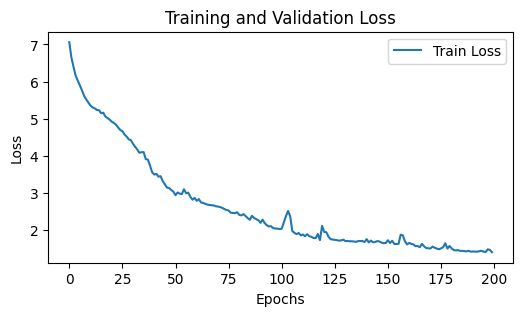

In [97]:
plt.figure(figsize=(6, 3))
plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

In [98]:
k_remainder_train_cdf = model.predict(input_data)
k_remainder_tain_pred = k_gev_dist.ppf(k_remainder_train_cdf)

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


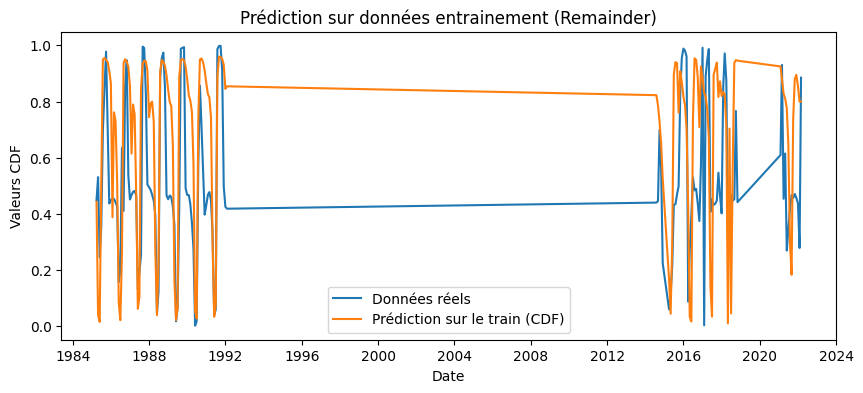

In [99]:
# @title Train forcasting
plt.figure(figsize=(10, 4))
plt.plot(
    k_month_date_series[lag: num_train],

    output_data,
    label='Données réels'
)
plt.plot(
    k_month_date_series[lag: num_train],
    k_remainder_train_cdf,
    label='Prédiction sur le train (CDF)'
)
plt.xlabel('Date')
plt.ylabel('Valeurs CDF')
plt.legend()
plt.title('Prédiction sur données entrainement (Remainder)')
plt.show()

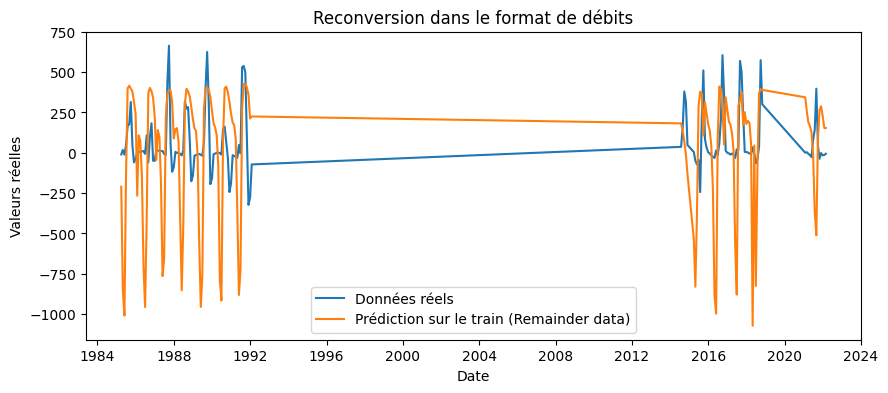

In [100]:
plt.figure(figsize=(10, 4))
plt.plot(
    k_month_date_series[lag: num_train],
    k_remainder[lag: num_train],
    label='Données réels'
)
plt.plot(
    k_month_date_series[lag: num_train],
    k_remainder_tain_pred,
    label='Prédiction sur le train (Remainder data)'
)
plt.xlabel('Date')
plt.ylabel('Valeurs réelles')
plt.legend()
plt.title('Reconversion dans le format de débits')
plt.show()

In [101]:
# On utilise les mêmes proportions et le même scaler que pour l'entraînement
test_frac = 0.85
n = features.shape[0] # Utilise le tableau des 4 variables
num_test = int(n * test_frac)

test_input = []
test_output = []

for i in range(num_test, n):
    # ICI : On prend les 4 colonnes et on aplatit (.flatten)
    # pour obtenir les 48 entrées attendues (12 lag * 4 variables)
    test_input.append(features[i - lag:i, :].flatten())

    # La cible reste la CDF du débit
    test_output.append([k_remainder_series_cdf[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

print(f'Test Input Data Shape: {test_input.shape}') # Doit être (X, 48)
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (33, 200)
Test Output Data Shape: (33, 1)


In [102]:
#-------------------------------------------
#     LSTM / GRU Alternative
#-------------------------------------------
test_input = []
test_output = []

# Assure-toi que lag = 50 ici pour correspondre au train (146, 50, 4)
lag = 50

for i in range(num_test, n):
    # SURTOUT PAS de .flatten() pour un LSTM
    test_input.append(features[i - lag:i, :])
    test_output.append([k_remainder_series_cdf[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

# Le shape doit être (37, 50, 4)
print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (33, 50, 4)
Test Output Data Shape: (33, 1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


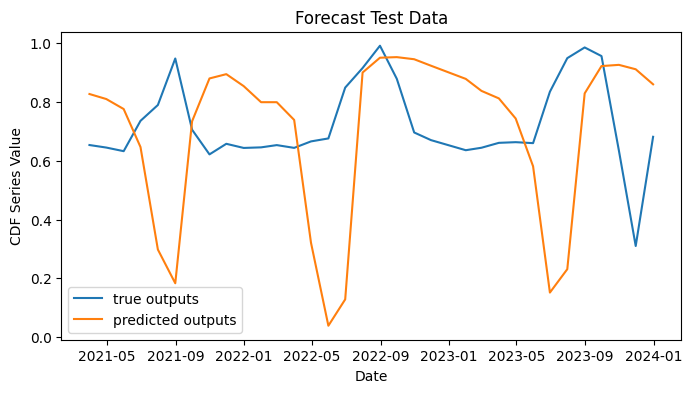

In [103]:
k_remainder_test_cdf = model.predict(test_input)
k_remainder_test_prd = k_gev_dist.ppf(k_remainder_test_cdf)

plt.figure(figsize=(8, 4))
plt.plot(
    k_month_date_series[num_test:],
    test_output,
    label='true outputs'
)
plt.plot(
    k_month_date_series[num_test:],
    k_remainder_test_cdf,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('CDF Series Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

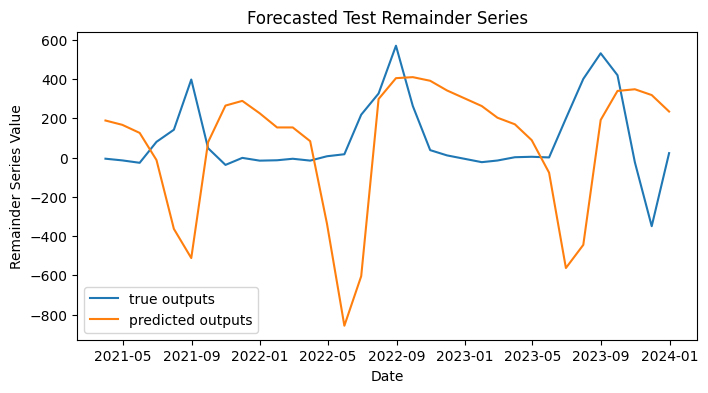

In [104]:
plt.figure(figsize=(8, 4))
plt.plot(
    k_month_date_series[num_test:],
    k_remainder[num_test:],
    label='true outputs'
)
plt.plot(
    k_month_date_series[num_test:],
    k_remainder_test_prd,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('Remainder Series Value')
plt.legend()
plt.title('Forecasted Test Remainder Series')
plt.show()

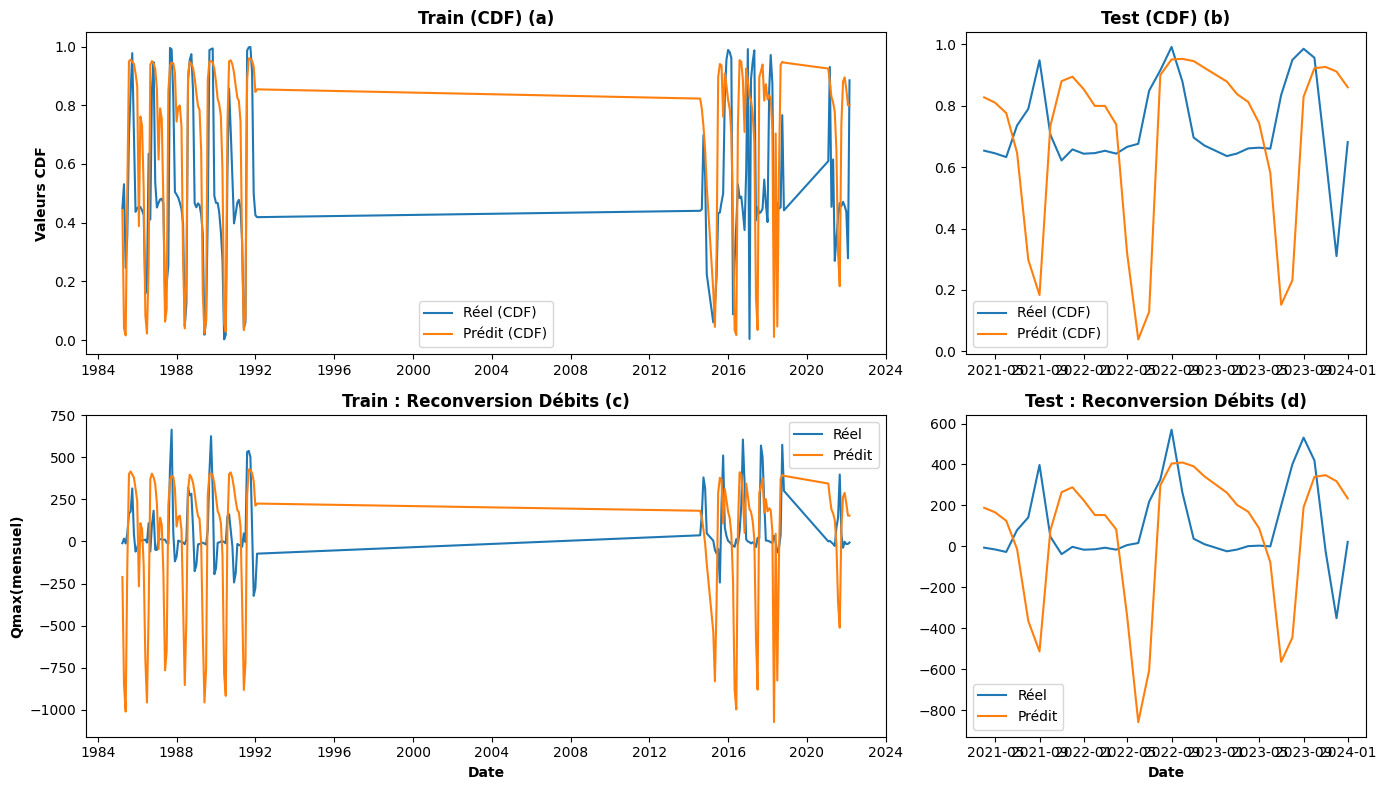

In [105]:
import matplotlib.pyplot as plt

# Configuration des polices
title_p = {'fontsize': 12, 'fontweight': 'bold'}
label_p = {'fontsize': 10, 'fontweight': 'bold'}

# Création de la figure 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8),
                       gridspec_kw={'width_ratios': [2, 1]})

# Définition des longueurs pour éviter l'erreur de dimension
n_train = output_data.shape[0]
n_test = test_output.shape[0]

# ==========================================
# LIGNE 1 : ESPACE CDF (PROBABILITÉS)
# ==========================================

# TRAIN CDF (Utilise les n_train premiers éléments après le lag)
axes[0, 0].plot(k_month_date_series[lag:lag+n_train], output_data, label='Réel (CDF)')
axes[0, 0].plot(k_month_date_series[lag:lag+n_train], k_remainder_train_cdf, label='Prédit (CDF)')
axes[0, 0].set_title("Train (CDF) (a)", **title_p)
axes[0, 0].set_ylabel("Valeurs CDF", **label_p)
axes[0, 0].legend()

# TEST CDF (Utilise les n_test derniers éléments de la série de dates)
axes[0, 1].plot(k_month_date_series[-n_test:], test_output, label='Réel (CDF)')
axes[0, 1].plot(k_month_date_series[-n_test:], k_remainder_test_cdf, label='Prédit (CDF)')
axes[0, 1].set_title("Test (CDF) (b)", **title_p)
axes[0, 1].legend()

# ==========================================
# LIGNE 2 : ESPACE DÉBITS (RECONVERSION)
# ==========================================

# TRAIN REMAINDER
axes[1, 0].plot(k_month_date_series[lag:lag+n_train], k_remainder[lag:lag+n_train], label='Réel')
axes[1, 0].plot(k_month_date_series[lag:lag+n_train], k_remainder_tain_pred, label='Prédit')
axes[1, 0].set_title("Train : Reconversion Débits (c)", **title_p)
axes[1, 0].set_ylabel("Qmax(mensuel)", **label_p)
axes[1, 0].set_xlabel("Date", **label_p)
axes[1, 0].legend()

# TEST REMAINDER
axes[1, 1].plot(k_month_date_series[-n_test:], k_remainder[-n_test:], label='Réel')
axes[1, 1].plot(k_month_date_series[-n_test:], k_remainder_test_prd, label='Prédit')
axes[1, 1].set_title("Test : Reconversion Débits (d)", **title_p)
axes[1, 1].set_xlabel("Date", **label_p)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

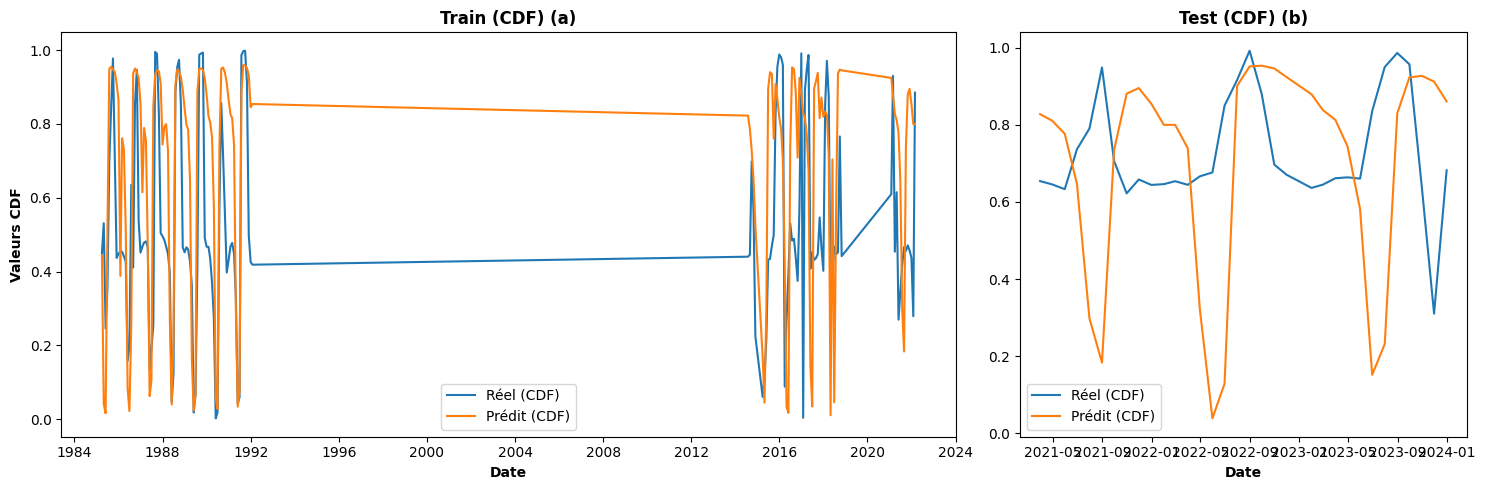

In [106]:
# ==========================================
# FIGURE 1 : ESPACE CDF (PROBABILITÉS)
# ==========================================
fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(15, 5),
                         gridspec_kw={'width_ratios': [2, 1]})

# TRAIN CDF
axes1[0].plot(k_month_date_series[lag:lag+n_train], output_data, label='Réel (CDF)')
axes1[0].plot(k_month_date_series[lag:lag+n_train], k_remainder_train_cdf, label='Prédit (CDF)')
axes1[0].set_title("Train (CDF) (a)", **title_p)
axes1[0].set_ylabel("Valeurs CDF", **label_p)
axes1[0].set_xlabel("Date", **label_p)
axes1[0].legend()

# TEST CDF
axes1[1].plot(k_month_date_series[-n_test:], test_output, label='Réel (CDF)')
axes1[1].plot(k_month_date_series[-n_test:], k_remainder_test_cdf, label='Prédit (CDF)')
axes1[1].set_title("Test (CDF) (b)", **title_p)
axes1[1].set_xlabel("Date", **label_p)
axes1[1].legend()

plt.tight_layout()
plt.show()

In [107]:
# @title Trend Forcasting

# @title Trend Forcasting
lag =  12

model_trend = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation=None)
])

model_trend.build(input_shape=(None, lag))
model_trend.compile(
    optimizer=tf.optimizers.Adam(
        tf.optimizers.schedules.ExponentialDecay(
            0.01, 50, 0.9
        )
    ),
    loss=tf.losses.MeanSquaredError()
)

train_frac = 0.8
# n = Ttou_month_max.dropna
n = d_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(k_trend[i - lag:i])
    output_data.append([k_trend[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

print(f'Input Data Shape: {input_data.shape}')
print(f'Output Data Shape: {output_data.shape}')

Input Data Shape: (184, 12)
Output Data Shape: (184, 1)


/tmp/ipykernel_12555/830977649.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_data.append([k_trend[i]])


In [108]:
history = model_trend.fit(input_data,
                          output_data,
                          verbose = 0,
                          # callbacks = ,
                          epochs=100)

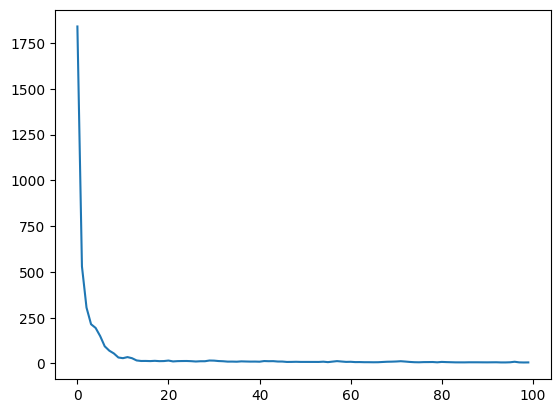

In [109]:
plt.plot(history.history['loss'])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


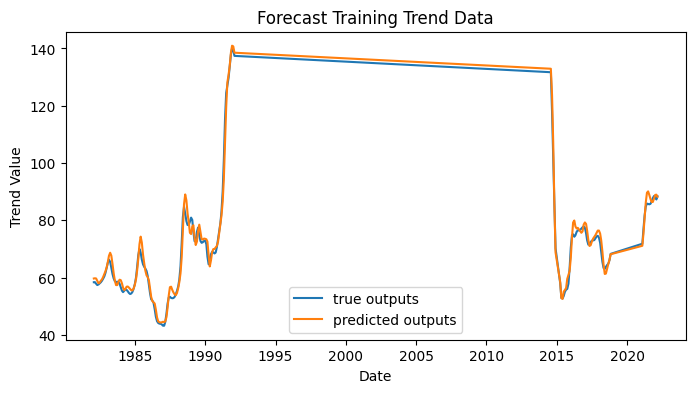

In [110]:
# @title Train trend Forcastiing
k_trend_train_pred = model_trend.predict(input_data)

plt.figure(figsize=(8, 4))
plt.plot(
    k_month_date_series[lag: num_train],
    output_data,
    label='true outputs'
)
plt.plot(
    k_month_date_series[lag: num_train],
    k_trend_train_pred,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('Trend Value')
plt.legend()
plt.title('Forecast Training Trend Data')
plt.show()

In [111]:
test_frac = 0.85
n = k_remainder_series_cdf.shape[0]
num_test = int(n * test_frac)

In [112]:
# @title Test Trend Forcast
test_input = []
test_output = []

for i in range(num_test, n):
    test_input.append(k_trend[i - lag:i])
    test_output.append([k_trend[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (33, 12)
Test Output Data Shape: (33, 1)


/tmp/ipykernel_12555/809339747.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_output.append([k_trend[i]])


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


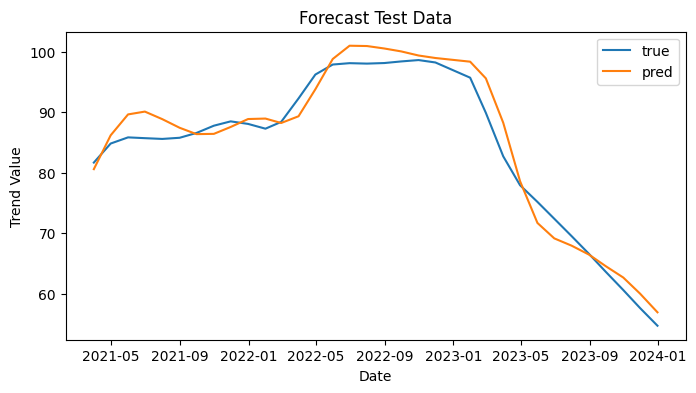

In [113]:
# @title Prédiction de la tedence sur les données de teste
k_trend_test_pred = model_trend.predict(test_input)

plt.figure(figsize=(8, 4))

plt.plot(
    k_month_date_series[num_test:],
    test_output,
    label='true'
)
plt.plot(
    k_month_date_series[num_test:],
    k_trend_test_pred,
    label='pred'
)
plt.xlabel('Date')
plt.ylabel('Trend Value')
plt.legend()
plt.title('Forecast Test Data')

plt.show()

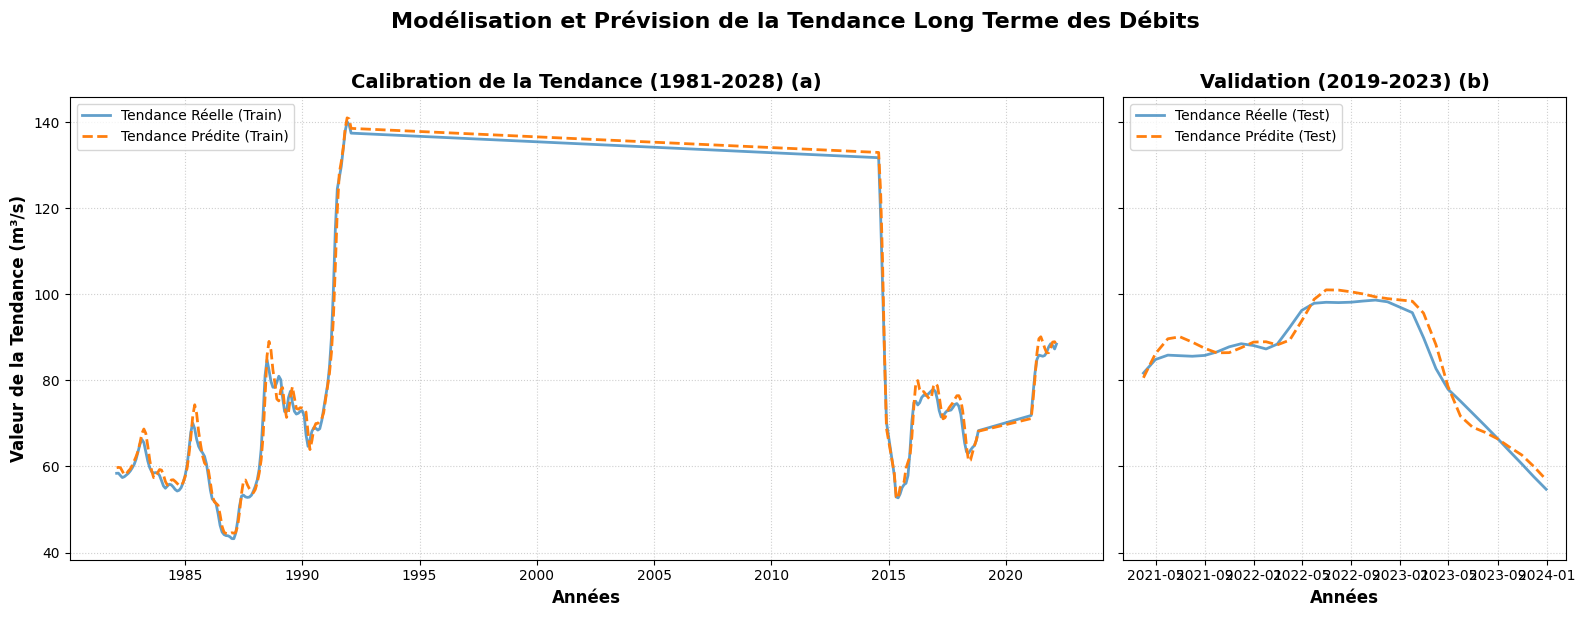

In [114]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Configuration des polices pour un rendu académique
title_p = {'fontsize': 14, 'fontweight': 'bold'}
label_p = {'fontsize': 12, 'fontweight': 'bold'}

# Création de la figure
fig = plt.figure(figsize=(16, 6))

# --- SOLUTION POUR LE RATIO 70/30 ---
# On utilise GridSpec pour définir des colonnes de largeurs inégales
# width_ratios=[7, 3] donne 70% à la première colonne et 30% à la deuxième
gs = gridspec.GridSpec(1, 2, width_ratios=[7, 3])

# Création des sous-graphiques (subplots)
ax_train = fig.add_subplot(gs[0])
ax_test = fig.add_subplot(gs[1], sharey=ax_train) # Partage de l'axe Y pour la comparaison

# ==========================================
# PARTIE 1 : ENTRAÎNEMENT (70% de largeur)
# ==========================================
ax_train.plot(
    k_month_date_series[lag: num_train],
    output_data,
    label='Tendance Réelle (Train)',
    color='#1f77b4', # Bleu standard
    alpha=0.7,
    linewidth=2
)
ax_train.plot(
    k_month_date_series[lag: num_train],
    k_trend_train_pred,
    label='Tendance Prédite (Train)',
    color='#ff7f0e', # Orange standard
    linestyle='--',
    linewidth=2
)

ax_train.set_title('Calibration de la Tendance (1981-2028) (a)', **title_p)
ax_train.set_xlabel('Années', **label_p)
ax_train.set_ylabel('Valeur de la Tendance (m³/s)', **label_p)
ax_train.legend(loc='upper left', fontsize=10)
ax_train.grid(True, linestyle=':', alpha=0.6)

# ==========================================
# PARTIE 2 : TEST (30% de largeur)
# ==========================================
ax_test.plot(
    k_month_date_series[num_test:],
    test_output,
    label='Tendance Réelle (Test)',
    color='#1f77b4',
    alpha=0.7,
    linewidth=2
)
ax_test.plot(
    k_month_date_series[num_test:],
    k_trend_test_pred,
    label='Tendance Prédite (Test)',
    color='#ff7f0e',
    linestyle='--',
    linewidth=2
)

ax_test.set_title('Validation (2019-2023) (b)', **title_p)
ax_test.set_xlabel('Années', **label_p)
# On cache le label Y du test car il est partagé avec le train (sharey=True)
plt.setp(ax_test.get_yticklabels(), visible=False)
ax_test.legend(loc='upper left', fontsize=10)
ax_test.grid(True, linestyle=':', alpha=0.6)

# --- TITRE GÉNÉRAL DE LA FIGURE ---
fig.suptitle("Modélisation et Prévision de la Tendance Long Terme des Débits",
             fontsize=16, fontweight='bold', y=1.02)

# Ajustement automatique des espaces
plt.tight_layout()
plt.show()

In [115]:
# @title Saisonality forcasting
k_seasonality_train = k_seasonal[:num_train][lag:]

season_values = k_seasonal[:num_train][-12:]
k_seasonality_test = np.zeros((n - num_test, 1))

for i in range(n - num_test):
    k_seasonality_test[i] = season_values[i % 12]

/tmp/ipykernel_12555/3028818298.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  k_seasonality_test[i] = season_values[i % 12]


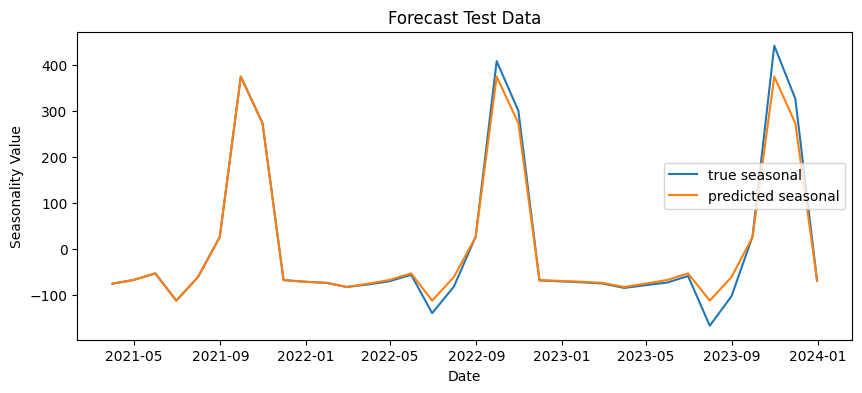

In [116]:
# @title Prédiction de la saisonnalité sur les données de teste
plt.figure(figsize=(10, 4))

plt.plot(
    k_month_date_series[num_test:],
    k_seasonal[num_test:],
    label='true seasonal'
)
plt.plot(
    k_month_date_series[num_test:],
    k_seasonality_test,
    label='predicted seasonal'
)
plt.xlabel('Date')
plt.ylabel('Seasonality Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

In [117]:
# @title Maximum deschage Forcast
print(k_remainder_tain_pred.shape, k_trend_train_pred.shape, k_seasonality_train.shape)
print(k_remainder_test_prd.shape, k_trend_test_pred.shape, k_seasonality_test.shape)

(146, 1) (184, 1) (184,)
(33, 1) (33, 1) (33, 1)


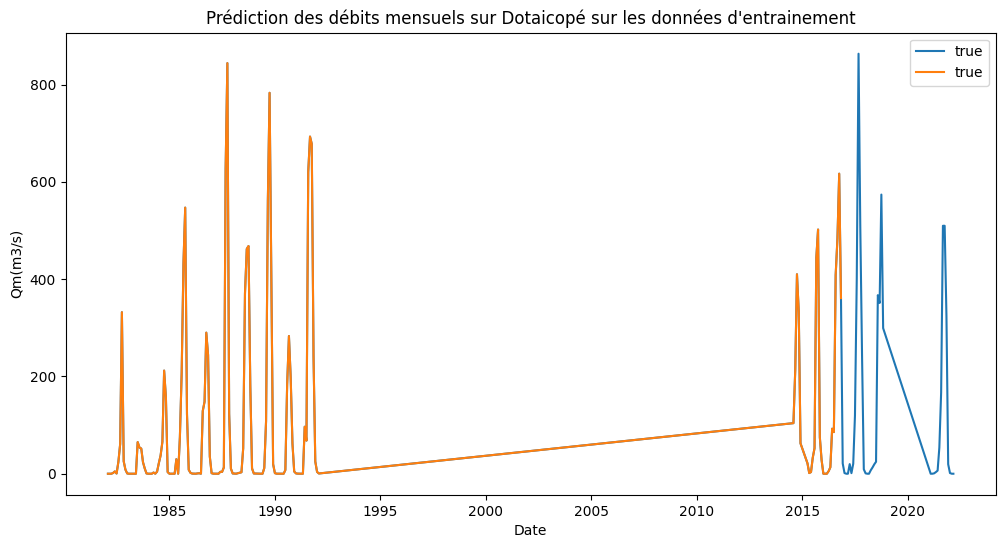

In [121]:
# @title Prédiction des débits mensuels sur les données d'entrainement
# pred_train = np.maximum(d_remainder_tain_pred.flatten() + d_trend_train_pred.flatten() + d_seasonality_train, 0)
pred_train = np.maximum(k_remainder_tain_pred.flatten() + k_trend_train_pred.flatten()[:146] + k_seasonality_train[:146], 0)
true_train = Klkp_month_max[:num_train][lag:]

plt.figure(figsize=(12, 6))

plt.plot(
    k_month_date_series[lag: num_train],
    true_train,
    label='true'
)

plt.plot(
    # k_month_date_series[lag: num_train],
    # pred_train,
    # label='pred'
    k_month_date_series[lag: num_train][:len(pred_train)], # Ajoute [:len(pred_train)]
    true_train[:len(pred_train)],                          # Ajoute [:len(pred_train)]
    label='true'
)

plt.title("Prédiction des débits mensuels sur Dotaicopé sur les données d'entrainement")
plt.xlabel('Date')
plt.ylabel('Qm(m3/s)')
plt.legend()
plt.show()

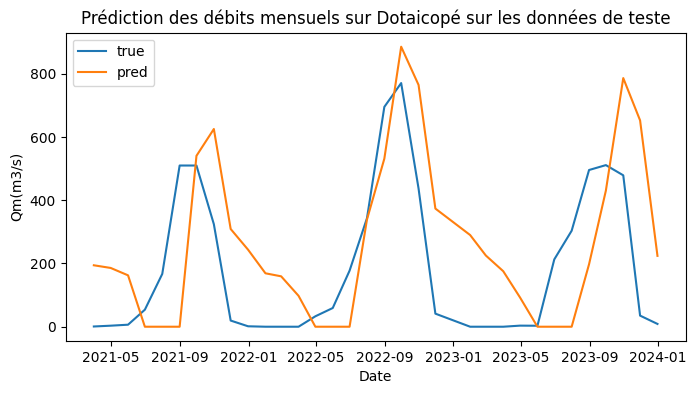

In [119]:
# @title Prédiction des débits mensuels sur les données de teste
pred_test = np.maximum(k_remainder_test_prd + k_trend_test_pred + k_seasonality_test, 0)
true_test = Klkp_month_max[num_test:]

plt.figure(figsize=(8, 4))

plt.plot(
    k_month_date_series[num_test:],
    true_test,
    label='true'
)
plt.plot(
    k_month_date_series[num_test:],
    pred_test,
    label='pred'
)
plt.title("Prédiction des débits mensuels sur Dotaicopé sur les données de teste")
plt.xlabel('Date')
plt.ylabel('Qm(m3/s)')
plt.legend()
plt.show()

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# --- Calcul des données ---
# pred_train = np.maximum(d_remainder_tain_pred.flatten() + d_trend_train_pred.flatten() + d_seasonality_train, 0)
pred_train = np.maximum(k_remainder_tain_pred.flatten() + k_trend_train_pred.flatten()[:146] + k_seasonality_train[;146], 0)
true_train = Klkp_month_max[:num_train][lag:]

pred_test = np.maximum(k_remainder_test_prd + k_trend_test_pred + k_seasonality_test, 0)
true_test = Klkp_month_max[num_test:]

# --- Configuration de la figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), gridspec_kw={'width_ratios': [3, 2]})

# Paramètres de style communs
font_title = {'weight': 'bold', 'size': 16}
font_label = {'weight': 'bold', 'size': 14}

# --- Graphique 1 : Entraînement ---
ax1.plot(k_month_date_series[lag: num_train], true_train, label='true', linewidth=2.5)
ax1.plot(k_month_date_series[lag: num_train], pred_train, label='pred', linewidth=2.5, alpha=0.8)

ax1.set_title("Prédiction des débits mensuels sur Dotaicopé (Entraînement)", fontdict=font_title, pad=15)
ax1.set_xlabel('Date', fontdict=font_label)
ax1.set_ylabel('Qm (m3/s)', fontdict=font_label)
ax1.legend(fontsize=12, loc='upper right')
ax1.tick_params(axis='both', which='major', labelsize=12) # Taille des chiffres sur les axes

# --- Graphique 2 : Test ---
ax2.plot(k_month_date_series[num_test:], true_test, label='true', linewidth=2.5)
ax2.plot(k_month_date_series[num_test:], pred_test, label='pred', linewidth=2.5, alpha=0.8)

ax2.set_title("Prédiction (Test)", fontdict=font_title, pad=15)
ax2.set_xlabel('Date', fontdict=font_label)
ax2.set_ylabel('Qm (m3/s)', fontdict=font_label)
ax2.legend(fontsize=12, loc='upper right')
ax2.tick_params(axis='both', which='major', labelsize=12)

# Ajustement final
plt.tight_layout()

# Pour un rendu très net dans un notebook ou lors de l'enregistrement
# plt.savefig('prediction_debit.png', dpi=300)
plt.show()

SyntaxError: invalid syntax (2862181880.py, line 6)

In [123]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score, f1_score

def get_hydrology_report(y_true, y_pred, label="Modèle", threshold_percentile=75):
    """
    Calcule et affiche un rapport complet de métriques hydrologiques.
    """
    # Nettoyage des données (suppression des NaNs éventuels)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    true = np.array(y_true)[mask]
    pred = np.array(y_pred)[mask]

    # --- 1. Métriques de Régression (Erreur Globale) ---
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)

    # --- 2. Efficacité Hydrologique (NSE & KGE) ---
    # Nash-Sutcliffe Efficiency
    nse = 1 - (np.sum((true - pred)**2) / np.sum((true - np.mean(true))**2))

    # Kling-Gupta Efficiency (KGE 2009)
    r = np.corrcoef(true, pred)[0, 1]
    alpha = np.std(pred) / np.std(true)
    beta = np.mean(pred) / np.mean(true)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    # --- 3. Métriques de Classification (Extrêmes / POT) ---
    threshold = np.percentile(true, threshold_percentile)
    true_bin = (true >= threshold).astype(int)
    pred_bin = (pred >= threshold).astype(int)

    prec = precision_score(true_bin, pred_bin, zero_division=0)
    rec = recall_score(true_bin, pred_bin, zero_division=0)
    f1 = f1_score(true_bin, pred_bin, zero_division=0)

    # Affichage structuré
    print(f"--- Rapport de Performance : {label} ---")
    print(f"Seuil ({threshold_percentile}ème perc.) : {threshold:.4f}")
    print(f"{'RMSE:':<15} {rmse:.4f}")
    print(f"{'MAE:':<15} {mae:.4f}")
    print(f"{'NSE:':<15} {nse:.4f}")
    print(f"{'KGE:':<15} {kge:.4f}")
    print(f"{'Précision:':<15} {prec:.4f}")
    print(f"{'Rappel:':<15} {rec:.4f}")
    print(f"{'F1-Score:':<15} {f1:.4f}")
    print("-" * 40)

    return {
        "rmse": rmse, "mae": mae, "nse": nse, "kge": kge,
        "precision": prec, "recall": rec, "f1": f1
    }

In [46]:
# @title Sequential
# --- APPLICATION ---

# 1. Sur le Remainder (en utilisant tes variables de test)
# Note : Si tu es en espace CDF [0,1], le seuil sera entre 0 et 1
results_rem = get_hydrology_report(
    k_remainder[num_test:],
    k_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 199.0460
RMSE:           135.8286
MAE:            101.7724
NSE:            0.5020
KGE:            0.4294
Précision:      0.7143
Rappel:         0.5556
F1-Score:       0.6250
----------------------------------------


In [48]:
# 2. Sur la Reconstitution Totale (Débits réels)
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 343.0000
RMSE:           119.4115
MAE:            74.1232
NSE:            0.7367
KGE:            0.7901
Précision:      0.8571
Rappel:         0.6667
F1-Score:       0.7500
----------------------------------------


In [80]:
# @title LSTM

# @title Sequential
# --- APPLICATION ---

# 1. Sur le Remainder (en utilisant tes variables de test)
# Note : Si tu es en espace CDF [0,1], le seuil sera entre 0 et 1
results_rem = get_hydrology_report(
    k_remainder[num_test:],
    k_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 199.0460
RMSE:           229.6259
MAE:            147.6063
NSE:            -0.4234
KGE:            -0.2976
Précision:      0.4667
Rappel:         0.7778
F1-Score:       0.5833
----------------------------------------


In [81]:
# 2. Sur la Reconstitution Totale (Débits réels)
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 343.0000
RMSE:           216.5782
MAE:            135.8150
NSE:            0.1337
KGE:            0.2867
Précision:      0.7273
Rappel:         0.8889
F1-Score:       0.8000
----------------------------------------


In [124]:
# @title GRU

# @title Sequential
# --- APPLICATION ---

# 1. Sur le Remainder (en utilisant tes variables de test)
# Note : Si tu es en espace CDF [0,1], le seuil sera entre 0 et 1
results_rem = get_hydrology_report(
    k_remainder[num_test:],
    k_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 199.0460
RMSE:           409.8912
MAE:            318.3477
NSE:            -3.5354
KGE:            -0.4139
Précision:      0.2857
Rappel:         0.4444
F1-Score:       0.3478
----------------------------------------


In [125]:
# 2. Sur la Reconstitution Totale (Débits réels)
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 343.0000
RMSE:           240.2302
MAE:            199.4127
NSE:            -0.0658
KGE:            0.4033
Précision:      0.6667
Rappel:         0.6667
F1-Score:       0.6667
----------------------------------------


----
Modeles univarié

In [ ]:
# @title Decomposition STL
def stl_decompose(series):

    stl = STL(
        series,
        period=12,
        seasonal=101,
        robust=True
    )

    res = stl.fit()

    return res.trend, res.seasonal, res.resid

# STL
# t_trend, t_seasonal, t_remainder = stl_decompose(Ttou_month_max['Qj'])
# d_trend, d_seasonal, d_remainder = stl_decompose(Dtkp_month_max['Qj'])
# k_trend, k_seasonal, k_remainder = stl_decompose(Klkp_month_max['Qj'])

import numpy as np

# On applique le log sur les séries originales avant STL (ou sur les residus, mais le mieux est avant)
t_log = np.log1p(Ttou_month_max['Qj'])
d_log = np.log1p(Dtkp_month_max['Qj'])
k_log = np.log1p(Klkp_month_max['Qj'])

# Refais ta décomposition STL sur ces versions log
t_trend, t_seasonal, t_remainder = stl_decompose(t_log)
# d_trend, d_seasonal, d_remainder = stl_decompose(d_log)
k_trend, k_seasonal, k_remainder = stl_decompose(k_log)

from scipy.stats import genextreme

# Fit GEV

t_c, t_loc, t_scale = genextreme.fit(t_remainder.values)
# d_c, d_loc, d_scale = genextreme.fit(d_remainder.values)
k_c, k_loc, k_scale = genextreme.fit(k_remainder.values)

t_trend, t_seasonal, t_remainder = stl_decompose(Ttou_month_max['Qj'])
d_trend, d_seasonal, d_remainder = stl_decompose(Dtkp_month_max['Qj'])
k_trend, k_seasonal, k_remainder = stl_decompose(Klkp_month_max['Qj'])

# Fit GEV

t_c, t_loc, t_scale = genextreme.fit(t_remainder.values, f0=-t_c)
d_c, d_loc, d_scale = genextreme.fit(d_remainder.values)
k_c, k_loc, k_scale = genextreme.fit(k_remainder.values, f0=-k_c)

#Distributions
t_gev_dist = genextreme(t_c, loc = t_loc, scale = t_scale)
d_gev_dist = genextreme(d_c, loc = d_loc, scale = d_scale)
k_gev_dist = genextreme(k_c, loc = k_loc, scale = k_scale)

# Transform to probability space
t_remainder_series_cdf = t_gev_dist.cdf(t_remainder)
d_remainder_series_cdf = d_gev_dist.cdf(d_remainder)
k_remainder_series_cdf = k_gev_dist.cdf(k_remainder)

In [ ]:
# @title Modèle Séquntiel
import tensorflow as tf

def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 40)  # Adjust the scale factor
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 10)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

# def tail_weighted_mse(y_true, y_pred):
#     # On utilise une exponentielle directe sur y_true
#     # Plus y_true approche de 1, plus le poids explose
#     weights = tf.exp(y_true * 10)
#     return tf.reduce_mean(weights * tf.square(y_true - y_pred))

lag = 24

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.build(input_shape=(None, lag))

model.compile(
    optimizer='adam',
    # loss=tf.losses.MeanSquaredError() # original loss
    loss=tail_weighted_mse,
    # loss=dual_tail_weighted_mse,
    # loss='mse',
    #metrics=[tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.MeanAbsoluteError()]
)

train_frac = 0.85
# n = Ttou_month_max.dropna
n = d_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

input_data = []
output_data = []

for i in range(lag, num_train):
    # input_data.append(np.squeeze(t_remainder_series_cdf[i - lag:i], axis=1))
    input_data.append(k_remainder_series_cdf[i - lag:i])
    output_data.append([k_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

print(f'Input Data Shape: {input_data.shape}')
print(f'Output Data Shape: {output_data.shape}')

Input Data Shape: (396, 24)
Output Data Shape: (396, 1)


In [ ]:
# @title Modèle LSTM
# Nouveau modèle LSTM

import tensorflow as tf

def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 40)  # Adjust the scale factor
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 10)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def tail_weighted_mse(y_true, y_pred):
    # On utilise une exponentielle directe sur y_true
    # Plus y_true approche de 1, plus le poids explose
    weights = tf.exp(y_true * 10)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

lag = 12

model = tf.keras.Sequential([
    # On précise (lag, 1) car chaque pas de temps a 1 valeur
    tf.keras.layers.LSTM(16, input_shape=(lag, 1), return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Garde sigmoid si tu es en espace [0,1]
])

model.compile(
    optimizer='adam',
    loss=dual_tail_weighted_mse,
    # loss='mse',
    # loss=tail_weighted_mse
    )

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(k_remainder_series_cdf[i - lag:i])
    output_data.append([k_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

# --- LA MODIFICATION CRUCIALE POUR LE LSTM ---
# On passe de (Echantillons, 12) à (Echantillons, 12, 1)
input_data = input_data.reshape((input_data.shape[0], lag, 1))
output_data = np.array(output_data)

In [ ]:
# @title Modèle GRU

def tail_weighted_mse(y_true, y_pred):
    weights = tf.exp(tf.abs(y_true - 0.5) * 40)  # Adjust the scale factor
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

def dual_tail_weighted_mse(y_true, y_pred):
    # On pénalise fortement les erreurs quand y_true est proche de 0 OU de 1
    # On utilise le carré de la distance par rapport au centre (0.5)
    dist_from_center = tf.abs(y_true - 0.5)

    # Poids exponentiel : plus on s'éloigne de 0.5, plus le poids augmente
    weights = tf.exp(dist_from_center * 10)

    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

# def tail_weighted_mse(y_true, y_pred):
#     # On utilise une exponentielle directe sur y_true
#     # Plus y_true approche de 1, plus le poids explose
#     weights = tf.exp(y_true * 10)
#     return tf.reduce_mean(weights * tf.square(y_true - y_pred))

lag = 12

model = tf.keras.Sequential([
    # Le shape reste (lag, 1) pour l'univarié ou (lag, 4) pour le multivarié
    tf.keras.layers.GRU(32, input_shape=(lag, 1), return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Car tu prédis une CDF (0 à 1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer = optimizer,
    # optimizer='adam',
    # loss='mse',
    # loss = tail_weighted_mse,
    loss = dual_tail_weighted_mse
)

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(k_remainder_series_cdf[i - lag:i])
    output_data.append([k_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

# Rappel de la transformation nécessaire avant le fit()
input_data = input_data.reshape((input_data.shape[0], lag, 1))
output_data = output_data

In [ ]:
# @title Model LSTM - GRU
import numpy as np
import tensorflow as tf

lag = 24

# 1. Préparation des données (Identique à tes modèles précédents)
train_frac = 0.80
n = d_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(k_remainder_series_cdf[i - lag:i])
    output_data.append([k_remainder_series_cdf[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

# La modification pour le format 3D (comme pour tes LSTM/GRU)
input_data = input_data.reshape((input_data.shape[0], lag, 1))

# 2. Architecture Hybride (Entrée unifiée)
input_seq = tf.keras.Input(shape=(lag, 1))

# Branche LSTM
lstm_out = tf.keras.layers.LSTM(64, return_sequences=False)(input_seq)
y_main = tf.keras.layers.Dense(1)(lstm_out)

# Branche GRU
gru_out = tf.keras.layers.GRU(32, return_sequences=False)(input_seq)
y_correction = tf.keras.layers.Dense(1)(gru_out)

# Fusion par addition
final_output = tf.keras.layers.Add()([y_main, y_correction])

model = tf.keras.Model(inputs=input_seq, outputs=final_output)

# 3. Compilation et Entraînement
model.compile(
    optimizer='adam',
    loss=tail_weighted_mse
    )

history = model.fit(
    input_data,
    output_data,
    epochs=100,
    verbose=1
)

In [ ]:
hist = model.fit(input_data,
                 output_data,
                 epochs=300,
                 batch_size=16,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=10)],
                 verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


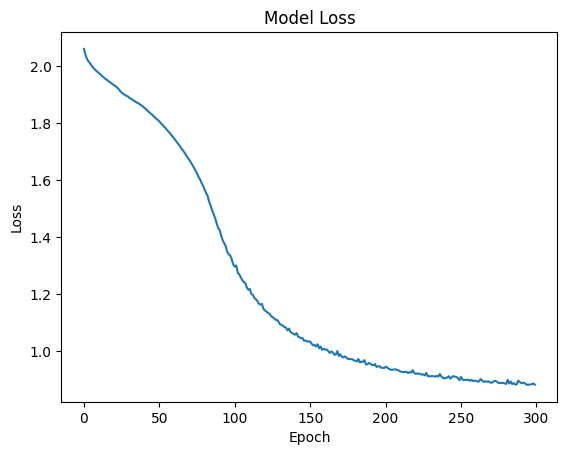

In [ ]:
plt.plot(hist.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
k_remainder_train_cdf = model.predict(input_data)
k_remainder_train_pred = d_gev_dist.ppf(k_remainder_train_cdf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


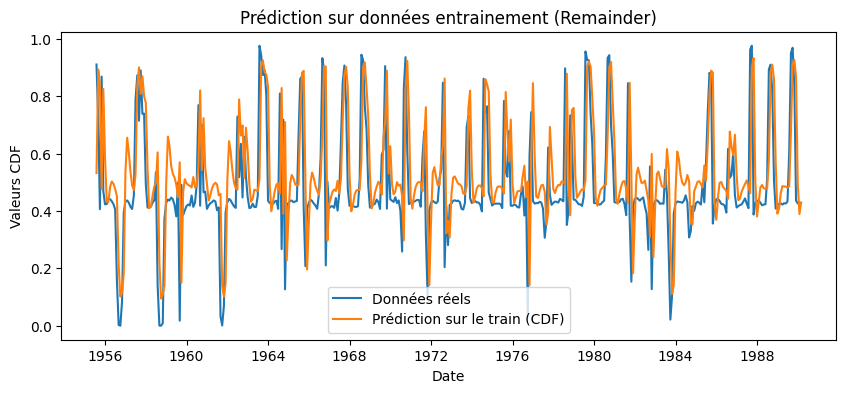

In [ ]:
# @title Train forcasting
plt.figure(figsize=(10, 4))
plt.plot(
    k_month_date_series[lag: num_train],
    output_data,
    label='Données réels'
)
plt.plot(
    k_month_date_series[lag: num_train],
    k_remainder_train_cdf,
    label='Prédiction sur le train (CDF)'
)
plt.xlabel('Date')
plt.ylabel('Valeurs CDF')
plt.legend()
plt.title('Prédiction sur données entrainement (Remainder)')
plt.show()

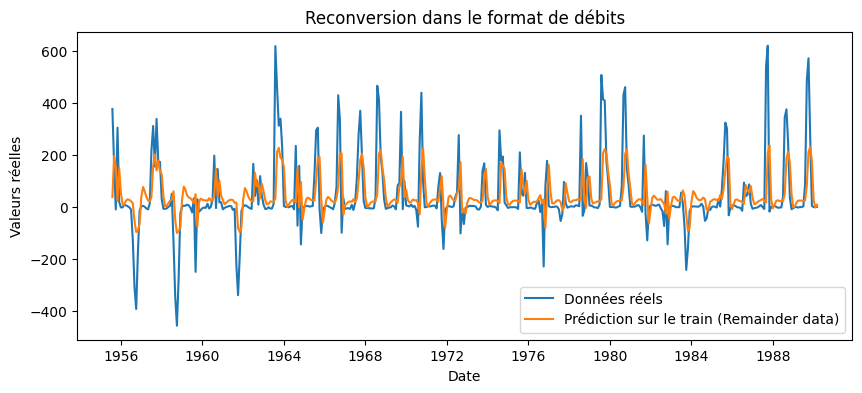

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(
    k_month_date_series[lag: num_train],
    k_remainder[lag: num_train],
    label='Données réels'
)
plt.plot(
    k_month_date_series[lag: num_train],
    k_remainder_train_pred,
    label='Prédiction sur le train (Remainder data)'
)
plt.xlabel('Date')
plt.ylabel('Valeurs réelles')
plt.legend()
plt.title('Reconversion dans le format de débits')
plt.show()

In [ ]:
test_frac = 0.85
n = k_remainder_series_cdf.shape[0]
num_test = int(n * test_frac)

In [ ]:
test_input = []
test_output = []

for i in range(num_test, n):
    test_input.append(k_remainder_series_cdf[i - lag:i])
    test_output.append([k_remainder_series_cdf[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (81, 12)
Test Output Data Shape: (81, 1)


In [ ]:
#---------------------------
#    LSTM - GRU
#---------------------------

test_input = []
test_output = []

for i in range(num_test, n):
    test_input.append(k_remainder_series_cdf[i - lag:i])
    test_output.append([k_remainder_series_cdf[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

# --- L'AJUSTEMENT POUR LE MODÈLE HYBRIDE ---
# On ajoute la dimension 1 pour que le shape soit (échantillons, lag, 1)
test_input = test_input.reshape((test_input.shape[0], lag, 1))

print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

# Maintenant la prédiction fonctionnera parfaitement
d_remainder_test_cdf = model.predict(test_input)

Test Input Data Shape: (81, 12, 1)
Test Output Data Shape: (81, 1)
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


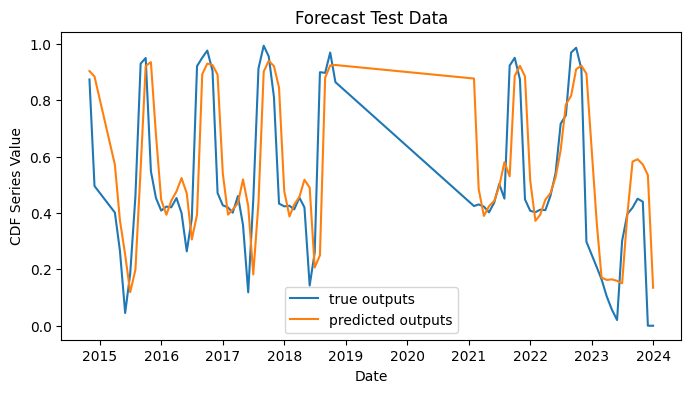

In [ ]:
k_remainder_test_cdf = model.predict(test_input)
k_remainder_test_prd = k_gev_dist.ppf(k_remainder_test_cdf)

plt.figure(figsize=(8, 4))
plt.plot(
    k_month_date_series[num_test:],
    test_output,
    label='true outputs'
)
plt.plot(
    k_month_date_series[num_test:],
    k_remainder_test_cdf,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('CDF Series Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

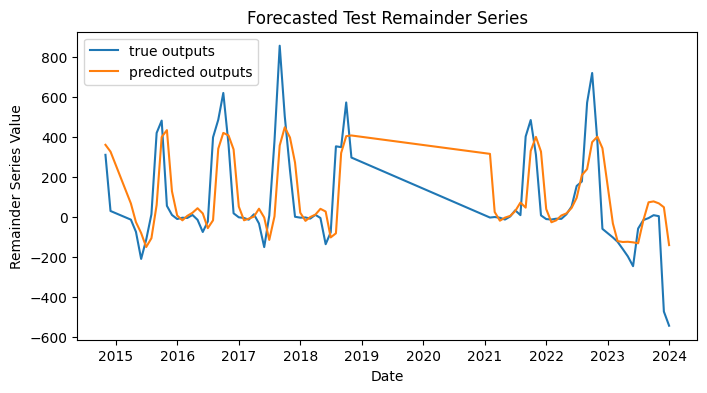

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(
    k_month_date_series[num_test:],
    k_remainder[num_test:],
    label='true outputs'
)
plt.plot(
    k_month_date_series[num_test:],
    k_remainder_test_prd,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('Remainder Series Value')
plt.legend()
plt.title('Forecasted Test Remainder Series')
plt.show()

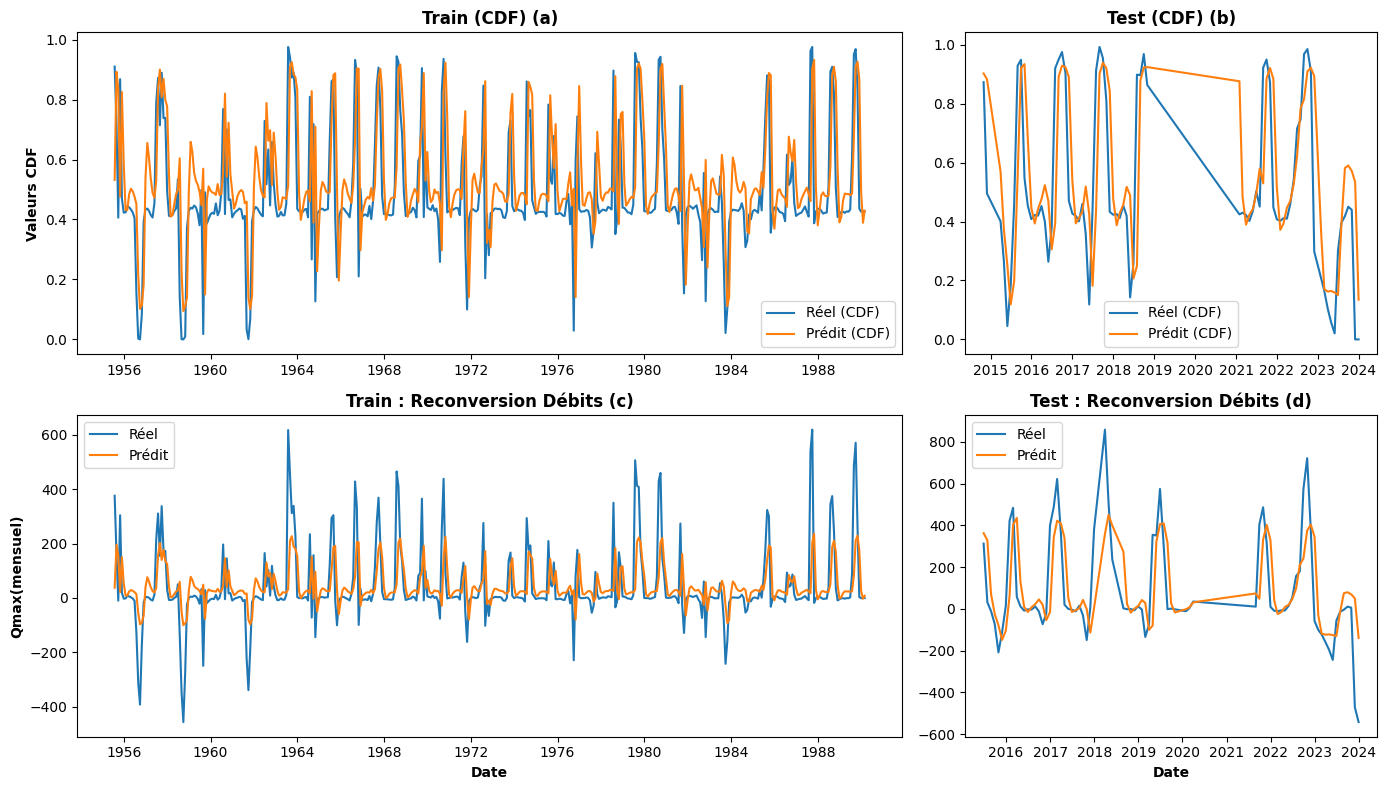

In [ ]:
import matplotlib.pyplot as plt

# Configuration des polices
title_p = {'fontsize': 12, 'fontweight': 'bold'}
label_p = {'fontsize': 10, 'fontweight': 'bold'}

# Création de la figure 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8),
                       gridspec_kw={'width_ratios': [2, 1]})

# Définition des longueurs pour éviter l'erreur de dimension
n_train = output_data.shape[0]
n_test = test_output.shape[0]

# ==========================================
# LIGNE 1 : ESPACE CDF (PROBABILITÉS)
# ==========================================

# TRAIN CDF (Utilise les n_train premiers éléments après le lag)
axes[0, 0].plot(k_month_date_series[lag:lag+n_train], output_data, label='Réel (CDF)')
axes[0, 0].plot(k_month_date_series[lag:lag+n_train], k_remainder_train_cdf, label='Prédit (CDF)')
axes[0, 0].set_title("Train (CDF) (a)", **title_p)
axes[0, 0].set_ylabel("Valeurs CDF", **label_p)
axes[0, 0].legend()

# TEST CDF (Utilise les n_test derniers éléments de la série de dates)
axes[0, 1].plot(k_month_date_series[-n_test:], test_output, label='Réel (CDF)')
axes[0, 1].plot(k_month_date_series[-n_test:], k_remainder_test_cdf, label='Prédit (CDF)')
axes[0, 1].set_title("Test (CDF) (b)", **title_p)
axes[0, 1].legend()

# ==========================================
# LIGNE 2 : ESPACE DÉBITS (RECONVERSION)
# ==========================================

# TRAIN REMAINDER
axes[1, 0].plot(k_month_date_series[lag:lag+n_train], k_remainder[lag:lag+n_train], label='Réel')
axes[1, 0].plot(k_month_date_series[lag:lag+n_train], k_remainder_train_pred, label='Prédit')
axes[1, 0].set_title("Train : Reconversion Débits (c)", **title_p)
axes[1, 0].set_ylabel("Qmax(mensuel)", **label_p)
axes[1, 0].set_xlabel("Date", **label_p)
axes[1, 0].legend()

# TEST REMAINDER
axes[1, 1].plot(t_month_date_series[-n_test:], k_remainder[-n_test:], label='Réel')
axes[1, 1].plot(t_month_date_series[-n_test:], k_remainder_test_prd, label='Prédit')
axes[1, 1].set_title("Test : Reconversion Débits (d)", **title_p)
axes[1, 1].set_xlabel("Date", **label_p)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# @title Trend Forcasting

# @title Trend Forcasting
lag = 50

model_trend = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation=None)
])

model_trend.build(input_shape=(None, lag))
model_trend.compile(
    optimizer=tf.optimizers.Adam(
        tf.optimizers.schedules.ExponentialDecay(
            0.01, 50, 0.9
        )
    ),
    loss=tf.losses.MeanSquaredError()
)

train_frac = 0.8
# n = Ttou_month_max.dropna
n = k_remainder_series_cdf.shape[0]
num_train = int(n * train_frac)

input_data = []
output_data = []

for i in range(lag, num_train):
    input_data.append(d_trend[i - lag:i])
    output_data.append([d_trend[i]])

input_data = np.array(input_data)
output_data = np.array(output_data)

print(f'Input Data Shape: {input_data.shape}')
print(f'Output Data Shape: {output_data.shape}')

Input Data Shape: (378, 50)
Output Data Shape: (378, 1)


/tmp/ipykernel_2675/2928525174.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_data.append([d_trend[i]])


In [ ]:
history = model_trend.fit(input_data,
                          output_data,
                          verbose = 0,
                          # callbacks = ,
                          epochs=100)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


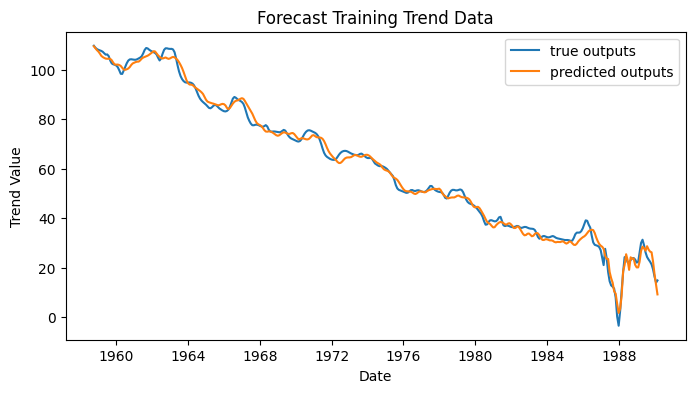

In [ ]:
# @title Train trend Forcastiing
k_trend_train_pred = model_trend.predict(input_data)

plt.figure(figsize=(8, 4))
plt.plot(
    k_month_date_series[lag: num_train],
    output_data,
    label='true outputs'
)
plt.plot(
    k_month_date_series[lag: num_train],
    k_trend_train_pred,
    label='predicted outputs'
)
plt.xlabel('Date')
plt.ylabel('Trend Value')
plt.legend()
plt.title('Forecast Training Trend Data')
plt.show()

In [ ]:
test_frac = 0.85
n = k_remainder_series_cdf.shape[0]
num_test = int(n * test_frac)

In [ ]:
# @title Test Trend Forcast
test_input = []
test_output = []

for i in range(num_test, n):
    test_input.append(k_trend[i - lag:i])
    test_output.append([k_trend[i]])

test_input = np.array(test_input)
test_output = np.array(test_output)

print(f'Test Input Data Shape: {test_input.shape}')
print(f'Test Output Data Shape: {test_output.shape}')

Test Input Data Shape: (81, 50)
Test Output Data Shape: (81, 1)


/tmp/ipykernel_2675/809339747.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_output.append([k_trend[i]])


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


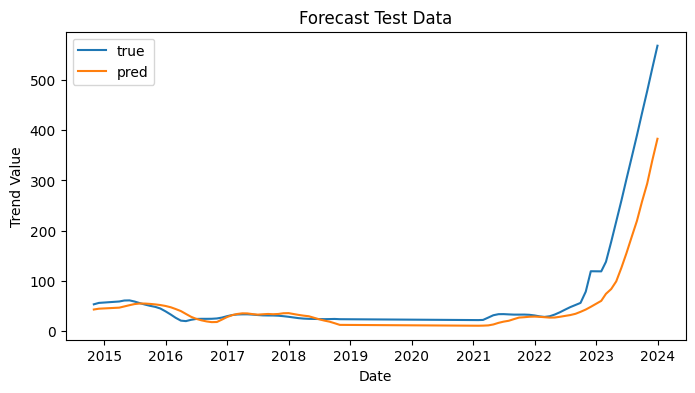

In [ ]:
# @title Prédiction de la tedence sur les données de teste
k_trend_test_pred = model_trend.predict(test_input)

plt.figure(figsize=(8, 4))

plt.plot(
    k_month_date_series[num_test:],
    test_output,
    label='true'
)
plt.plot(
    k_month_date_series[num_test:],
    k_trend_test_pred,
    label='pred'
)
plt.xlabel('Date')
plt.ylabel('Trend Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

In [ ]:
test_frac = 0.85
n = k_remainder_series_cdf.shape[0]
num_test = int(n * test_frac)

In [ ]:
# @title Saisonality forcasting
k_seasonality_train = k_seasonal[:num_train][lag:]

season_values = k_seasonal[:num_train][-12:]
k_seasonality_test = np.zeros((n - num_test, 1))

for i in range(n - num_test):
    k_seasonality_test[i] = season_values[i % 12]

/tmp/ipykernel_2675/3028818298.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  k_seasonality_test[i] = season_values[i % 12]


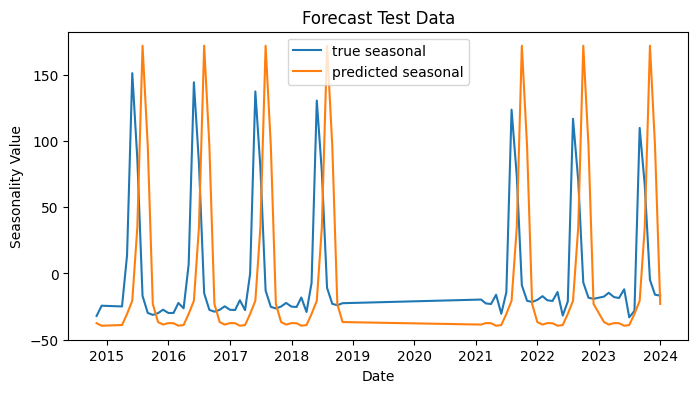

In [ ]:
# @title Prédiction de la saisonnalité sur les données de teste
plt.figure(figsize=(8, 4))

plt.plot(
    k_month_date_series[num_test:],
    k_seasonal[num_test:],
    label='true seasonal'
)
plt.plot(
    k_month_date_series[num_test:],
    k_seasonality_test,
    label='predicted seasonal'
)
plt.xlabel('Date')
plt.ylabel('Seasonality Value')
plt.legend()
plt.title('Forecast Test Data')
plt.show()

In [ ]:
# @title Maximum deschage Forcast
print(k_remainder_train_pred.shape, k_trend_train_pred.shape, k_seasonality_train.shape)
print(k_remainder_test_prd.shape, k_trend_test_pred.shape, k_seasonality_test.shape)

(416, 1) (378, 1) (378,)
(81, 1) (81, 1) (81, 1)


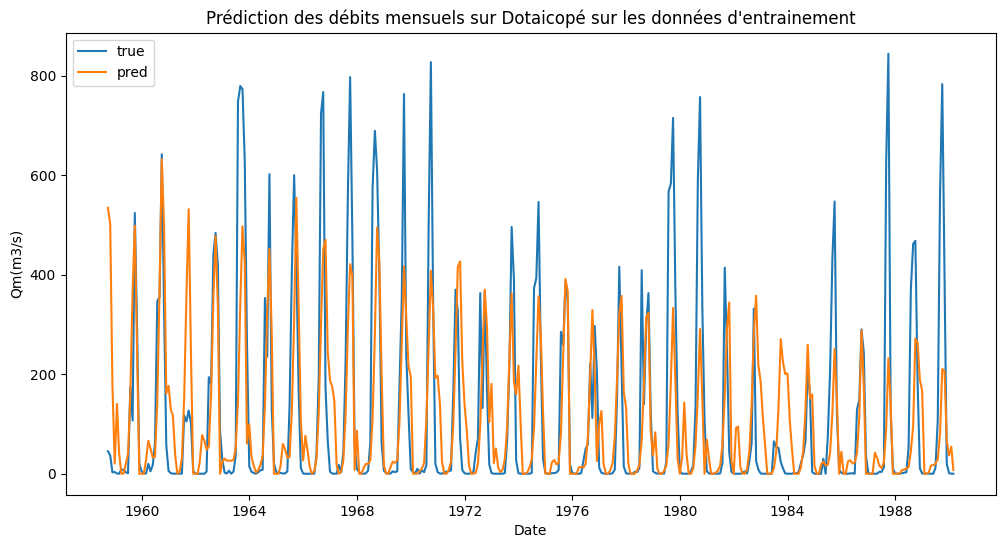

In [ ]:
# @title Prédiction des débits mensuels sur les données d'entrainement
pred_train = np.maximum(k_remainder_train_pred[:378].flatten() + k_trend_train_pred.flatten() + k_seasonality_train, 0)
true_train = Klkp_month_max[:num_train][lag:]

plt.figure(figsize=(12, 6))

plt.plot(
    k_month_date_series[lag: num_train],
    true_train,
    label='true'
)
plt.plot(
    k_month_date_series[lag: num_train],
    pred_train,
    label='pred'
)
plt.title("Prédiction des débits mensuels sur Dotaicopé sur les données d'entrainement")
plt.xlabel('Date')
plt.ylabel('Qm(m3/s)')
plt.legend()
plt.show()

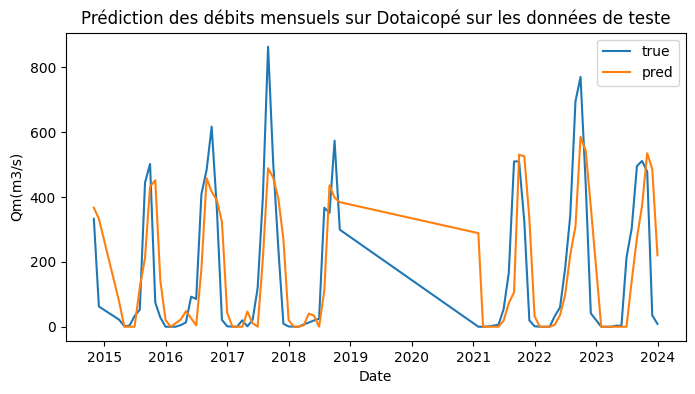

In [ ]:
# @title Prédiction des débits mensuels sur les données de teste
pred_test = np.maximum(k_remainder_test_prd + k_trend_test_pred + k_seasonality_test, 0)
true_test = Klkp_month_max[num_test:]

plt.figure(figsize=(8, 4))

plt.plot(
    k_month_date_series[num_test:],
    true_test,
    label='true'
)
plt.plot(
    k_month_date_series[num_test:],
    pred_test,
    label='pred'
)
plt.title("Prédiction des débits mensuels sur Dotaicopé sur les données de teste")
plt.xlabel('Date')
plt.ylabel('Qm(m3/s)')
plt.legend()
plt.show()

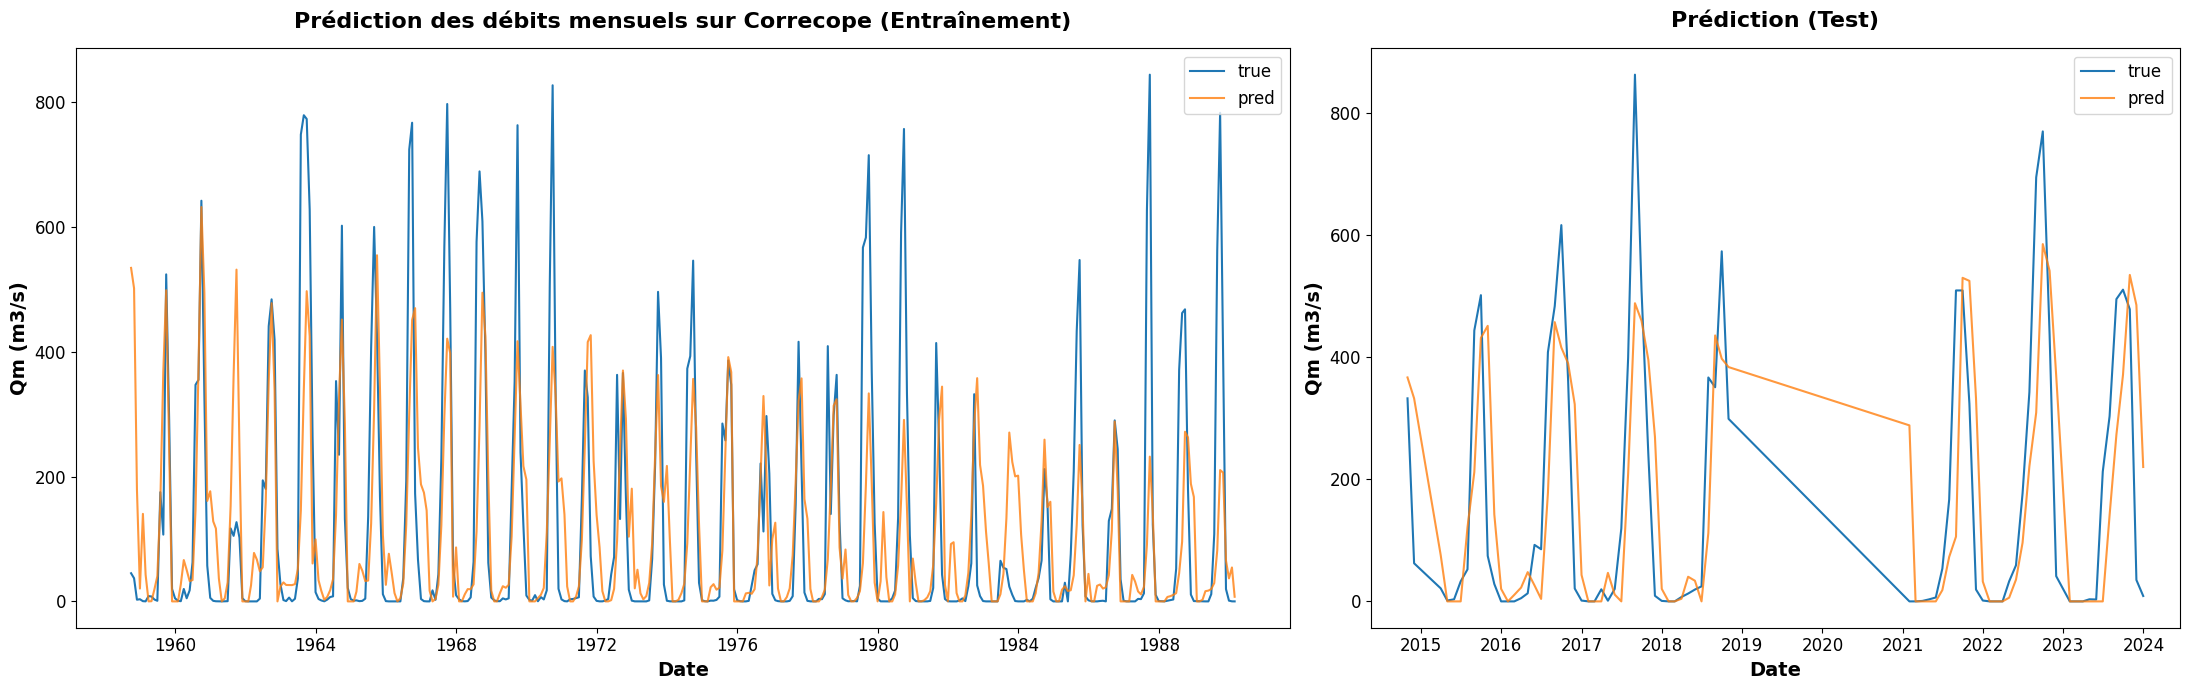

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Calcul des données ---
pred_train = np.maximum(k_remainder_train_pred[:num_train-50].flatten() + k_trend_train_pred.flatten() + k_seasonality_train, 0)
true_train = Klkp_month_max[:num_train][lag:]

pred_test = np.maximum(k_remainder_test_prd + k_trend_test_pred + k_seasonality_test, 0)
true_test = Klkp_month_max[num_test:]

# --- Configuration de la figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), gridspec_kw={'width_ratios': [3, 2]})

# Paramètres de style communs
font_title = {'weight': 'bold', 'size': 16}
font_label = {'weight': 'bold', 'size': 14}

# --- Graphique 1 : Entraînement ---
ax1.plot(k_month_date_series[lag: num_train], true_train, label='true', linewidth=1.5)
ax1.plot(k_month_date_series[lag: num_train], pred_train, label='pred', linewidth=1.5, alpha=0.8)

ax1.set_title("Prédiction des débits mensuels sur Correcope (Entraînement)", fontdict=font_title, pad=15)
ax1.set_xlabel('Date', fontdict=font_label)
ax1.set_ylabel('Qm (m3/s)', fontdict=font_label)
ax1.legend(fontsize=12, loc='upper right')
ax1.tick_params(axis='both', which='major', labelsize=12) # Taille des chiffres sur les axes

# --- Graphique 2 : Test ---
ax2.plot(k_month_date_series[num_test:], true_test, label='true', linewidth=1.5)
ax2.plot(k_month_date_series[num_test:], pred_test, label='pred', linewidth=1.5, alpha=0.8)

ax2.set_title("Prédiction (Test)", fontdict=font_title, pad=15)
ax2.set_xlabel('Date', fontdict=font_label)
ax2.set_ylabel('Qm (m3/s)', fontdict=font_label)
ax2.legend(fontsize=12, loc='upper right')
ax2.tick_params(axis='both', which='major', labelsize=12)

# Ajustement final
plt.tight_layout()

# Pour un rendu très net dans un notebook ou lors de l'enregistrement
# plt.savefig('prediction_debit.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score, f1_score

def get_hydrology_report(y_true, y_pred, label="Modèle", threshold_percentile=75):
    """
    Calcule et affiche un rapport complet de métriques hydrologiques.
    """
    # Nettoyage des données (suppression des NaNs éventuels)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    true = np.array(y_true)[mask]
    pred = np.array(y_pred)[mask]

    # --- 1. Métriques de Régression (Erreur Globale) ---
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)

    # --- 2. Efficacité Hydrologique (NSE & KGE) ---
    # Nash-Sutcliffe Efficiency
    nse = 1 - (np.sum((true - pred)**2) / np.sum((true - np.mean(true))**2))

    # Kling-Gupta Efficiency (KGE 2009)
    r = np.corrcoef(true, pred)[0, 1]
    alpha = np.std(pred) / np.std(true)
    beta = np.mean(pred) / np.mean(true)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    # --- 3. Métriques de Classification (Extrêmes / POT) ---
    threshold = np.percentile(true, threshold_percentile)
    true_bin = (true >= threshold).astype(int)
    pred_bin = (pred >= threshold).astype(int)

    prec = precision_score(true_bin, pred_bin, zero_division=0)
    rec = recall_score(true_bin, pred_bin, zero_division=0)
    f1 = f1_score(true_bin, pred_bin, zero_division=0)

    # Affichage structuré
    print(f"--- Rapport de Performance : {label} ---")
    print(f"Seuil ({threshold_percentile}ème perc.) : {threshold:.4f}")
    print(f"{'RMSE:':<15} {rmse:.4f}")
    print(f"{'MAE:':<15} {mae:.4f}")
    print(f"{'NSE:':<15} {nse:.4f}")
    print(f"{'KGE:':<15} {kge:.4f}")
    print(f"{'Précision:':<15} {prec:.4f}")
    print(f"{'Rappel:':<15} {rec:.4f}")
    print(f"{'F1-Score:':<15} {f1:.4f}")
    print("-" * 40)

    return {
        "rmse": rmse, "mae": mae, "nse": nse, "kge": kge,
        "precision": prec, "recall": rec, "f1": f1
    }

In [ ]:
# @title Modèle Séquentiel
# 1. Sur le Remainder (en utilisant tes variables de test)
# Note : Si tu es en espace CDF [0,1], le seuil sera entre 0 et 1
results_rem = get_hydrology_report(
    k_remainder[num_test:],
    k_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 235.1766
RMSE:           315.0630
MAE:            259.2314
NSE:            -0.6118
KGE:            0.1270
Précision:      0.6786
Rappel:         0.9048
F1-Score:       0.7755
----------------------------------------


In [ ]:
# 2. Sur la Reconstitution Totale (Débits réels)
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 343.0000
RMSE:           267.2256
MAE:            151.2842
NSE:            -0.4253
KGE:            0.0777
Précision:      0.6296
Rappel:         0.8095
F1-Score:       0.7083
----------------------------------------


In [ ]:
# @title Modèle LSTM

results_rem = get_hydrology_report(
    k_remainder[num_test:],
    k_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 235.1766
RMSE:           193.3358
MAE:            134.2345
NSE:            0.3931
KGE:            0.3851
Précision:      0.8000
Rappel:         0.5714
F1-Score:       0.6667
----------------------------------------


In [ ]:
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 343.0000
RMSE:           156.3853
MAE:            100.0456
NSE:            0.5119
KGE:            0.5339
Précision:      0.7692
Rappel:         0.4762
F1-Score:       0.5882
----------------------------------------


In [ ]:
# @title Modèle GRU

results_rem = get_hydrology_report(
    k_remainder[num_test:],
    k_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

--- Rapport de Performance : Remainder (CDF Space) ---
Seuil (75ème perc.) : 235.1766
RMSE:           186.8752
MAE:            124.1279
NSE:            0.4329
KGE:            0.5406
Précision:      0.6957
Rappel:         0.7619
F1-Score:       0.7273
----------------------------------------


In [ ]:
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

--- Rapport de Performance : Reconstitution Totale (Débits) ---
Seuil (75ème perc.) : 343.0000
RMSE:           157.5619
MAE:            103.1181
NSE:            0.5045
KGE:            0.6801
Précision:      0.6500
Rappel:         0.6190
F1-Score:       0.6341
----------------------------------------


In [ ]:
# @title Modèle LSTM - GRU

results_rem = get_hydrology_report(
    k_remainder[num_test:],
    k_remainder_test_prd.flatten(),
    label="Remainder (CDF Space)"
)

In [ ]:
results_final = get_hydrology_report(
    true_test,
    pred_test,
    label="Reconstitution Totale (Débits)"
)

----------------------
                                    
                                  LSTM - GRU -RF

In [ ]:
# @title Préparation et Mise en Forme (Data Engineering)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

df = Klkp_month_max.copy()

# Fonction pour le Nash-Sutcliffe Efficiency (NSE)
def compute_nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))

# 1. Préparation des séquences
def create_dataset(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Chargement (Assurez-vous que df est trié par date)
# df = pd.read_csv('votre_fichier.csv')
values = df['Qj'].values.reshape(-1, 1)

# Normalisation
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(values)

look_back = 12 # On utilise 1 an d'historique pour prédire le mois suivant
X, y = create_dataset(scaled_data, look_back)

# Split Train/Test (chronologique)
train_size = int(len(X) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape pour LSTM/GRU [samples, time steps, features]
X_train_dl = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test_dl = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
# @title RF
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train) # RF prend les données à plat

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
# @title LSTM - GRU
def build_model(model_type="LSTM"):
    model = Sequential()
    if model_type == "LSTM":
        model.add(LSTM(64, activation='relu', input_shape=(look_back, 1)))
    else:
        model.add(GRU(64, activation='relu', input_shape=(look_back, 1)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam',
                  # loss='mse',
                  loss=tail_weighted_mse
                  )
    return model

lstm_model = build_model("LSTM")
gru_model = build_model("GRU")

# Entraînement silencieux pour la clarté
lstm_model.fit(X_train_dl, y_train, epochs=100, batch_size=32, verbose=0)
gru_model.fit(X_train_dl, y_train, epochs=100, batch_size=32, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# @title Metrics evaluation
def get_metrics(model, X_input, y_true, name, is_dl=True):
    pred = model.predict(X_input)
    # Inverse scaling
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1))
    pred_inv = scaler.inverse_transform(pred.reshape(-1, 1))

    return {
        "Modèle": name,
        "RMSE": np.sqrt(mean_squared_error(y_true_inv, pred_inv)),
        "MAE": mean_absolute_error(y_true_inv, pred_inv),
        "R2": r2_score(y_true_inv, pred_inv),
        "NSE": compute_nse(y_true_inv, pred_inv),
        "Pred": pred_inv,
        "True": y_true_inv
    }

results_test = [
    get_metrics(rf_model, X_test, y_test, "Random Forest", False),
    get_metrics(lstm_model, X_test_dl, y_test, "LSTM"),
    get_metrics(gru_model, X_test_dl, y_test, "GRU")
]

summary = pd.DataFrame(results_test).drop(['Pred', 'True'], axis=1)
print(summary)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
          Modèle        RMSE         MAE        R2       NSE
0  Random Forest  118.434882   71.151315  0.749951  0.749951
1           LSTM  170.557535  105.608002  0.481430  0.481430
2            GRU  160.407641   94.862431  0.541314  0.541314


In [ ]:
def get_metrics(model, X_input, y_true, name, is_dl=True, threshold=0.75):
    # Prédiction
    if is_dl:
        pred = model.predict(X_input, verbose=0)
    else:
        pred = model.predict(X_input)

    # Inversion du scaling pour rester en m3/s
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
    pred_inv = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()

    # Calcul de l'erreur relative par point
    # On évite la division par zéro pour les débits nuls (étiage)
    relative_error = np.abs((y_true_inv - pred_inv) / (y_true_inv + 1.0))

    # Accuracy within threshold : pourcentage de points où l'erreur < seuil
    accuracy_threshold = np.mean(relative_error <= threshold) * 100

    return {
        "Modèle": name,
        "RMSE": np.sqrt(mean_squared_error(y_true_inv, pred_inv)),
        "MAE": mean_absolute_error(y_true_inv, pred_inv),
        "R2": r2_score(y_true_inv, pred_inv),
        "NSE": compute_nse(y_true_inv, pred_inv),
        f"Acc_{int(threshold*100)}% (%)": accuracy_threshold,
        "Pred": pred_inv,
        "True": y_true_inv
    }

# Relancer l'évaluation
results_test = [
    get_metrics(rf_model, X_test, y_test, "Random Forest", False),
    get_metrics(lstm_model, X_test_dl, y_test, "LSTM"),
    get_metrics(gru_model, X_test_dl, y_test, "GRU")
]

summary = pd.DataFrame(results_test).drop(['Pred', 'True'], axis=1)
print(summary.round(3))

          Modèle     RMSE      MAE     R2    NSE  Acc_75% (%)
0  Random Forest  118.435   71.151  0.750  0.750       60.377
1           LSTM  170.558  105.608  0.481  0.481       43.396
2            GRU  160.408   94.862  0.541  0.541       45.283


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_classification_metrics(y_true, y_pred, threshold_percentile=75):
    # 1. Calcul du seuil réel sur les données observées
    threshold = np.percentile(y_true, threshold_percentile)

    # 2. Transformation en labels binaires (1 = Crue, 0 = Normal)
    true_extreme = (y_true >= threshold).astype(int)
    pred_extreme = (y_pred >= threshold).astype(int)

    # 3. Calcul des métriques de classification
    precision = precision_score(true_extreme, pred_extreme, zero_division=0)
    recall = recall_score(true_extreme, pred_extreme, zero_division=0)
    f1 = f1_score(true_extreme, pred_extreme, zero_division=0)

    return threshold, precision, recall, f1

# Application aux trois modèles
extreme_results = []

for res in results_test: # On utilise les résultats stockés précédemment
    y_t = res['True'].flatten()
    y_p = res['Pred'].flatten()

    thresh, prec, rec, f1 = get_classification_metrics(y_t, y_p)

    extreme_results.append({
        "Modèle": res['Modèle'],
        "Seuil (m3/s)": round(thresh, 2),
        "Précision (Extrêmes)": round(prec, 3),
        "Rappel (Recall)": round(rec, 3),
        "F1-Score": round(f1, 3)
    })

df_extremes = pd.DataFrame(extreme_results)
print(df_extremes)

          Modèle  Seuil (m3/s)  Précision (Extrêmes)  Rappel (Recall)  \
0  Random Forest         351.0                 0.900            0.643   
1           LSTM         351.0                 0.857            0.429   
2            GRU         351.0                 0.900            0.643   

   F1-Score  
0     0.750  
1     0.571  
2     0.750  


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Choix de la station (ex: Tetetou)
series_qj = Ttou_month_max['Qj'].values.reshape(-1, 1)

# Normalisation entre 0 et 1
scaler_qj = MinMaxScaler(feature_range=(0, 1))
qj_scaled = scaler_qj.fit_transform(series_qj)

# Création des séquences
lag = 50
input_data = []
output_data = []

for i in range(lag, len(qj_scaled)):
    input_data.append(qj_scaled[i - lag:i])
    output_data.append(qj_scaled[i])

X = np.array(input_data)
y = np.array(output_data)

# Split Train/Test
train_size = int(len(X) * 0.8)
test_size = int(len(X) * 0.85)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_direct_hybrid_model(lag_shape):
    inputs = layers.Input(shape=(lag_shape, 1))

    # --- Branche 1 : LSTM (Débit de base) ---
    lstm_out = layers.LSTM(64, return_sequences=True)(inputs)
    lstm_out = layers.LSTM(32)(lstm_out)
    lstm_pred = layers.Dense(1, activation='linear', name='base_prediction')(lstm_out)

    # --- Branche 2 : GRU (Correction d'erreur brute) ---
    # Le GRU regarde le dernier débit connu et ce que le LSTM propose
    last_flow = inputs[:, -1, :]
    gru_input = layers.Concatenate()([last_flow, lstm_pred])

    gru_path = layers.Dense(32, activation='relu')(gru_input)
    # tanh permet de corriger en négatif ou positif
    correction = layers.Dense(1, activation='tanh', name='error_correction')(gru_path)

    # --- Fusion ---
    combined = layers.Add()([lstm_pred, correction])

    # Sécurité : ReLU pour garantir que le débit final n'est jamais négatif
    final_output = layers.Activation('relu')(combined)

    model = Model(inputs=inputs, outputs=final_output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_direct = build_direct_hybrid_model(lag)

In [ ]:
# Configuration de l'arrêt précoce pour surveiller la perte (Loss)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Lancement de l'entraînement
history = model_direct.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0420 - mae: 0.1463 - val_loss: 0.0248 - val_mae: 0.1045
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0296 - mae: 0.1261 - val_loss: 0.0216 - val_mae: 0.1034
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0250 - mae: 0.1142 - val_loss: 0.0201 - val_mae: 0.1016
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0225 - mae: 0.1083 - val_loss: 0.0195 - val_mae: 0.0972
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0204 - mae: 0.0965 - val_loss: 0.0194 - val_mae: 0.0935
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0191 - mae: 0.0862 - val_loss: 0.0184 - val_mae: 0.0957
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0184 - mae: 0.0892 - val_loss: 0.0185 - val_mae: 0.0948
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0174 - mae: 0.0860 - val_loss: 0.0200 - val_mae: 0.0949
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - l

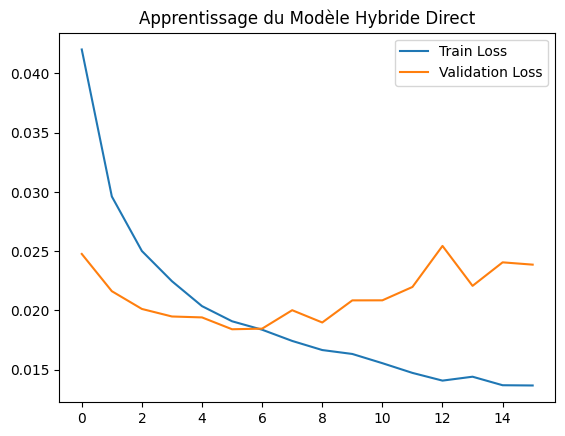

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Apprentissage du Modèle Hybride Direct')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Prédiction et dé-normalisation
y_pred_scaled = model_direct.predict(X_test)
y_pred = scaler_qj.inverse_transform(y_pred_scaled)
y_true = scaler_qj.inverse_transform(y_test)

def get_hydrology_metrics(true, pred):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)

    # Nash-Sutcliffe Efficiency (NSE)
    nse = 1 - (np.sum((true - pred)**2) / np.sum((true - np.mean(true))**2))

    print(f"--- Évaluation Directe ---")
    print(f"RMSE : {rmse:.2f} m3/s")
    print(f"MAE  : {mae:.2f} m3/s")
    print(f"R2   : {r2:.4f}")
    print(f"NSE  : {nse:.4f} (Cible > 0.6)")

get_hydrology_metrics(y_true, y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
--- Évaluation Directe ---
RMSE : 189.93 m3/s
MAE  : 133.95 m3/s
R2   : 0.3719
NSE  : 0.3719 (Cible > 0.6)


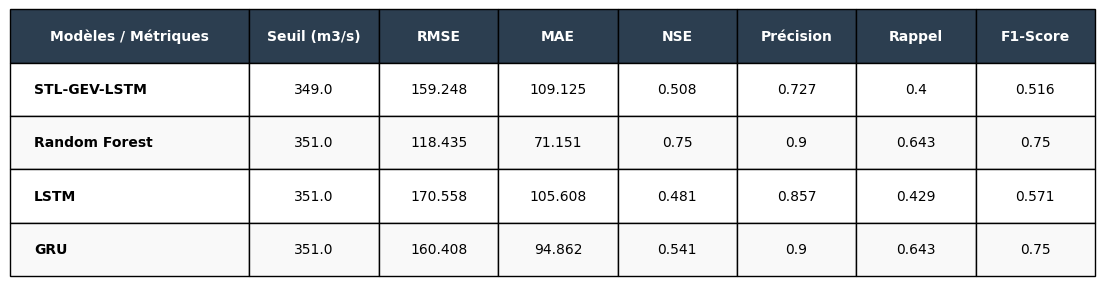

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Données pour Corrékopé (Seuil inclus)
# Structure : [Modèle, Seuil, RMSE, MAE, NSE, Précision, Rappel, F1-Score]
data = [
    ["STL-GEV-LSTM", 349.00, 159.248, 109.125, 0.508, 0.727, 0.400, 0.516],
    ["Random Forest", 351.00, 118.435, 71.151, 0.750, 0.900, 0.643, 0.750],
    ["LSTM", 351.00, 170.558, 105.608, 0.481, 0.857, 0.429, 0.571],
    ["GRU", 351.00, 160.408, 94.862, 0.541, 0.900, 0.643, 0.750]
]

columns = ["Modèles / Métriques", "Seuil (m3/s)", "RMSE", "MAE", "NSE", "Précision", "Rappel", "F1-Score"]
df = pd.DataFrame(data, columns=columns)

# 2. Configuration de la figure
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

# Ajustement des largeurs de colonnes
widths = [0.22, 0.12, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11]

# 3. Création du tableau
table = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 cellLoc='center',
                 loc='center',
                 colWidths=widths)

# 4. Style et correction de l'erreur de padding
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 3.2) # Hauteur de ligne

for (row, col), cell in table.get_celld().items():
    # Bordures systématiques
    cell.set_edgecolor('black')
    cell.set_linewidth(1)

    if row == 0:
        # En-tête
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    else:
        # Corps du tableau
        if col == 0:
            cell.set_text_props(weight='bold', ha='left')

        # Coloration alternée pour la lecture
        if row % 2 == 0:
            cell.set_facecolor('#f9f9f9')

# 5. Sauvegarde sans bordures blanches
plt.savefig("correkope_final_metrics.png",
            bbox_inches='tight',
            pad_inches=0.02,
            dpi=300)

plt.show()

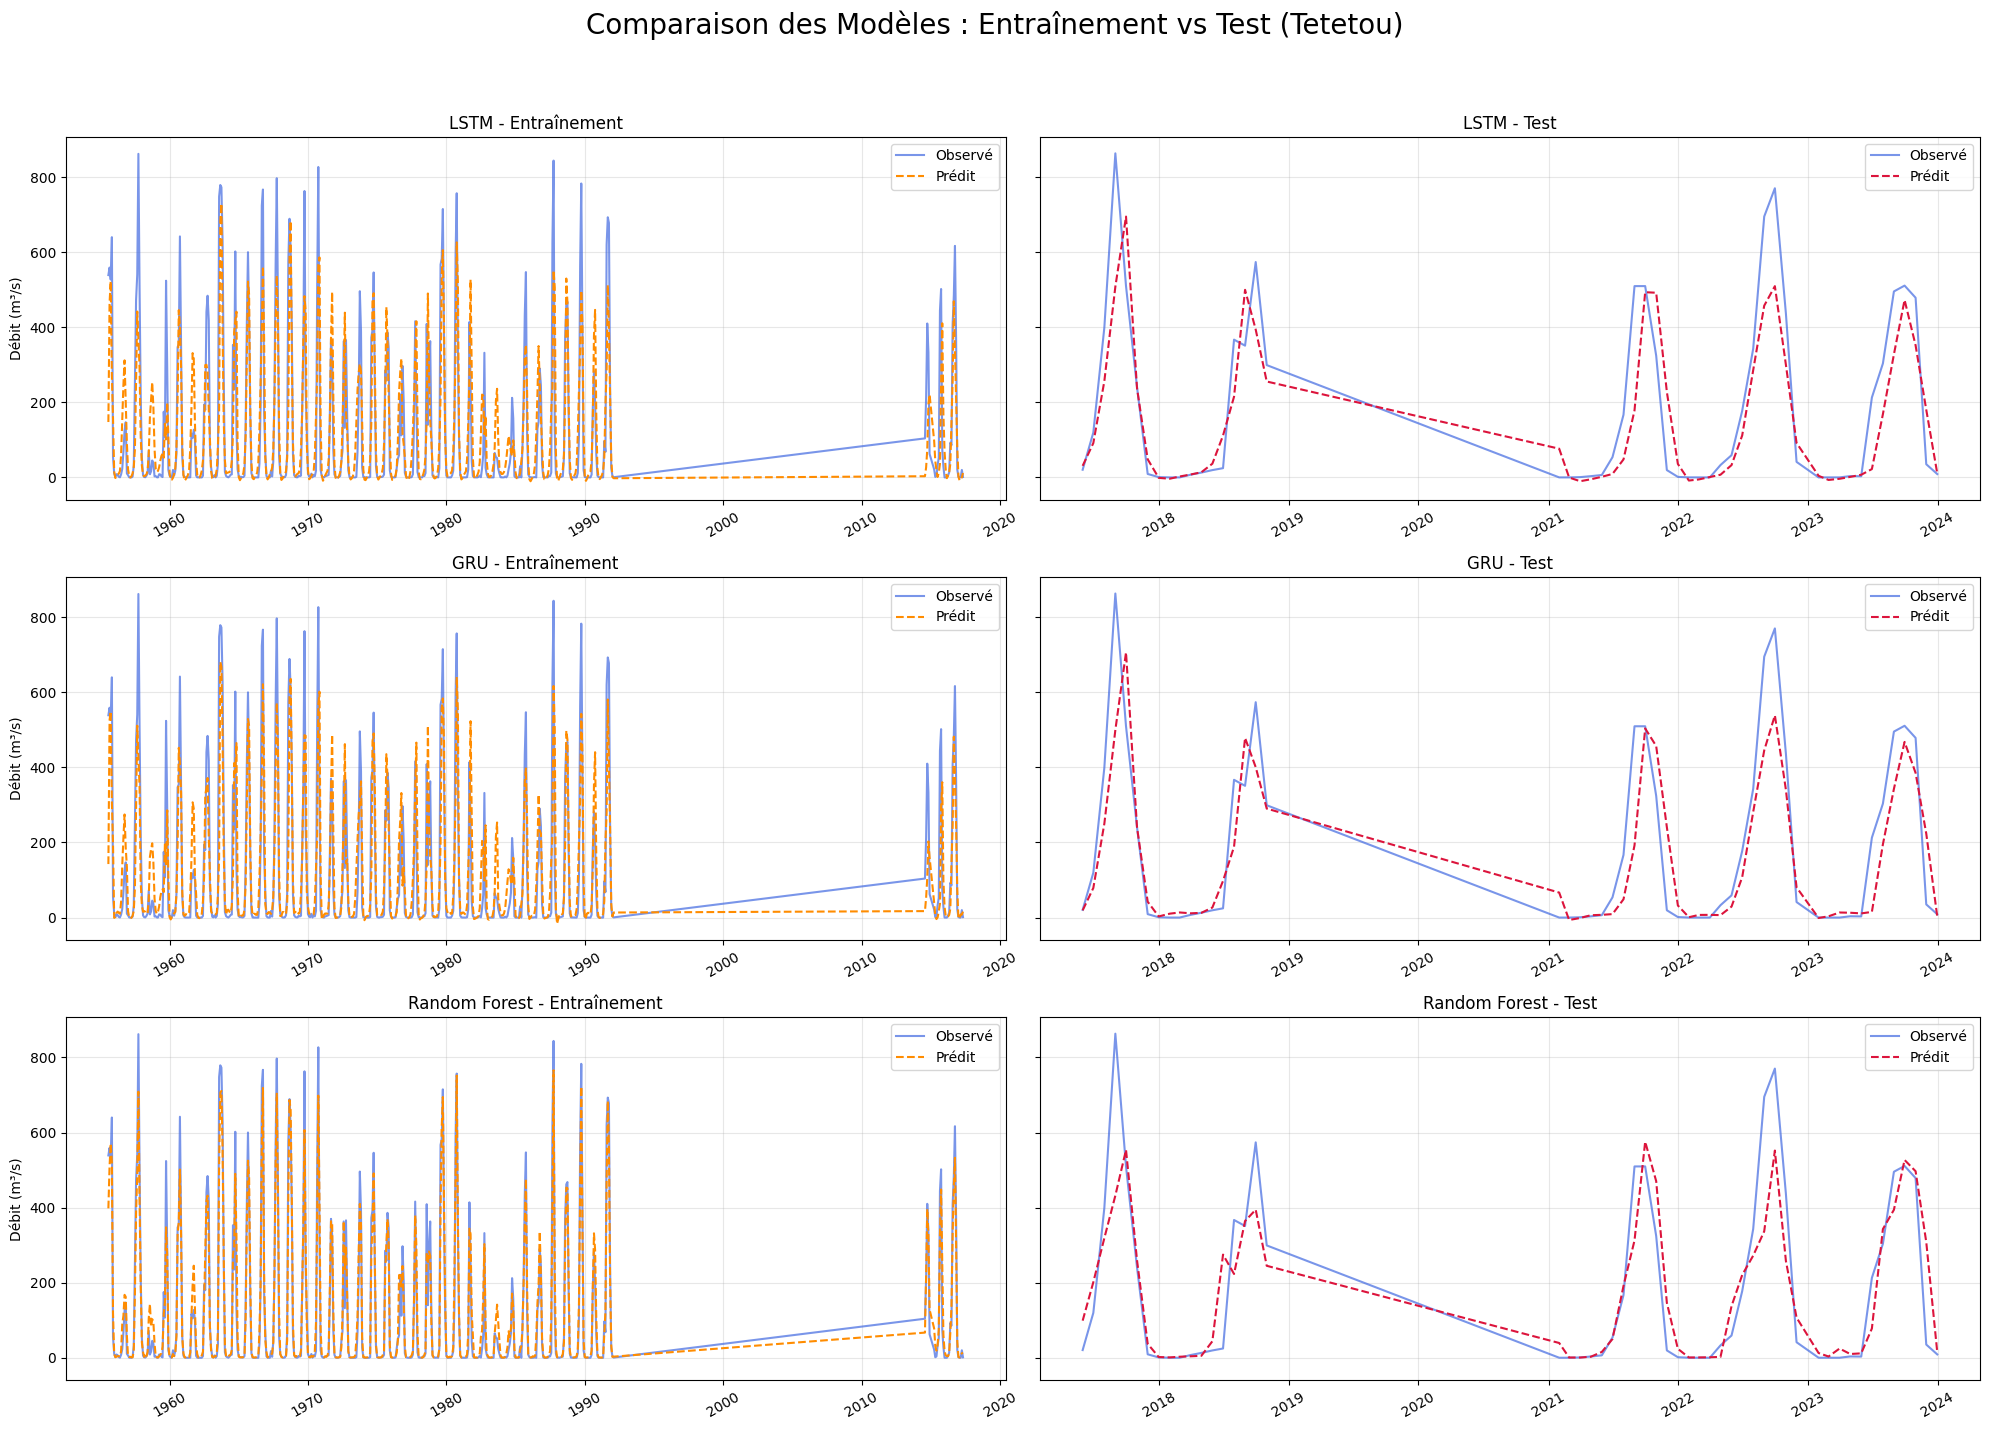

In [ ]:
# Dates pour les abscisses
dates_train = df.index[look_back : train_size + look_back]
dates_test = df.index[train_size + look_back :]

import matplotlib.pyplot as plt

# Liste des modèles pour la boucle
models_list = [
    (lstm_model, "LSTM", True),
    (gru_model, "GRU", True),
    (rf_model, "Random Forest", False)
]

fig, axes = plt.subplots(3, 2, figsize=(20, 15), sharey=True)
fig.suptitle("Comparaison des Modèles : Entraînement vs Test (Tetetou)", fontsize=20)

for i, (model, name, is_dl) in enumerate(models_list):
    # --- PRÉDICTIONS ---
    if is_dl:
        pred_train = model.predict(X_train_dl, verbose=0)
        pred_test = model.predict(X_test_dl, verbose=0)
    else:
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)

    # Inversion du scaling
    y_train_true_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
    y_train_pred_inv = scaler.inverse_transform(pred_train.reshape(-1, 1))
    y_test_true_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_test_pred_inv = scaler.inverse_transform(pred_test.reshape(-1, 1))

    # --- COLONNE 1 : ENTRAÎNEMENT ---
    axes[i, 0].plot(dates_train, y_train_true_inv, label='Observé', color='royalblue', alpha=0.7)
    axes[i, 0].plot(dates_train, y_train_pred_inv, label='Prédit', color='darkorange', linestyle='--')
    axes[i, 0].set_title(f"{name} - Entraînement")
    axes[i, 0].set_ylabel("Débit (m³/s)")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].legend()

    # --- COLONNE 2 : TEST ---
    axes[i, 1].plot(dates_test, y_test_true_inv, label='Observé', color='royalblue', alpha=0.7)
    axes[i, 1].plot(dates_test, y_test_pred_inv, label='Prédit', color='crimson', linestyle='--')
    axes[i, 1].set_title(f"{name} - Test")
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].legend()

# Ajustement automatique des dates sur l'axe X
for ax in axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=30)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()